In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## **H1**

In [5]:
df = pd.read_csv("dataset/H1_dataset_weekly.csv", parse_dates=["publication_date", "week_ended"])

# publication_date is the reference date of each observation, so it is used as the time
# index for the time-based views that follow.
ts = df.set_index("publication_date")

print(df.shape)
df.head()

(1861, 13)


,publication_date,week_ended,target_stock_change,crude_stocks,production,refinery_util,refiner_net_input,commercial_imports,wti_m1,gprd,gprd_act,gprd_threat,igrea
0,1990-11-07,1990-11-02,4158.0,331392,7342.0,84.0,12898,4917,34.72,128.985000,103.858333,157.738333,-18.609531
1,1990-11-14,1990-11-09,1644.0,333036,7284.0,83.0,12684,4419,33.86,146.140000,92.320000,189.578333,-18.609531
2,1990-11-21,1990-11-16,-5743.0,327293,6910.0,84.0,12764,5637,31.41,150.308333,92.141667,209.955000,-18.609531
3,1990-11-28,1990-11-23,-3025.0,324268,7440.0,84.0,12779,5610,30.49,168.275000,142.723333,184.381667,-18.609531
4,1990-12-05,1990-11-30,2587.0,326855,7235.0,89.0,13711,4532,32.17,185.646667,115.896667,238.568333,-14.594048


### **EDA**

#### **1. Data integrity**

Every later test assumes a clean, regularly spaced series. Missing values, duplicate
reference dates, or irregular gaps would distort the stationarity tests, the autocorrelations
and the seasonal decomposition. The gap between two consecutive releases should be 7 days
almost everywhere; any other value points to a missing or shifted week.

In [6]:
print("Missing values per column:")
print(df.isna().sum())

print("\nDuplicate publication_date:", df["publication_date"].duplicated().sum())
print("Strictly increasing:", df["publication_date"].is_monotonic_increasing
      and df["publication_date"].duplicated().sum() == 0)

gaps = df["publication_date"].diff().dt.days.value_counts().sort_index()
print("\nGap in days between consecutive releases (count):")
print(gaps)


Missing values per column:
publication_date       0
week_ended             0
target_stock_change    0
crude_stocks           0
production             0
refinery_util          0
refiner_net_input      0
commercial_imports     0
wti_m1                 0
gprd                   0
gprd_act               0
gprd_threat            0
igrea                  0
dtype: int64

Duplicate publication_date: 0
Strictly increasing: True

Gap in days between consecutive releases (count):
publication_date
7.0    1860
Name: count, dtype: int64


#### **2. Series in level**


Each series is plotted over the full sample to spot structural breaks and outliers by eye.
The April 2020 window is shaded on every chart: the COVID demand collapse — including the
one-day negative WTI settlement on 20 April 2020 — is a known, extreme episode. Marking it
keeps it from being read as a data error and flags it for conscious treatment so it does not
silently drive a model.

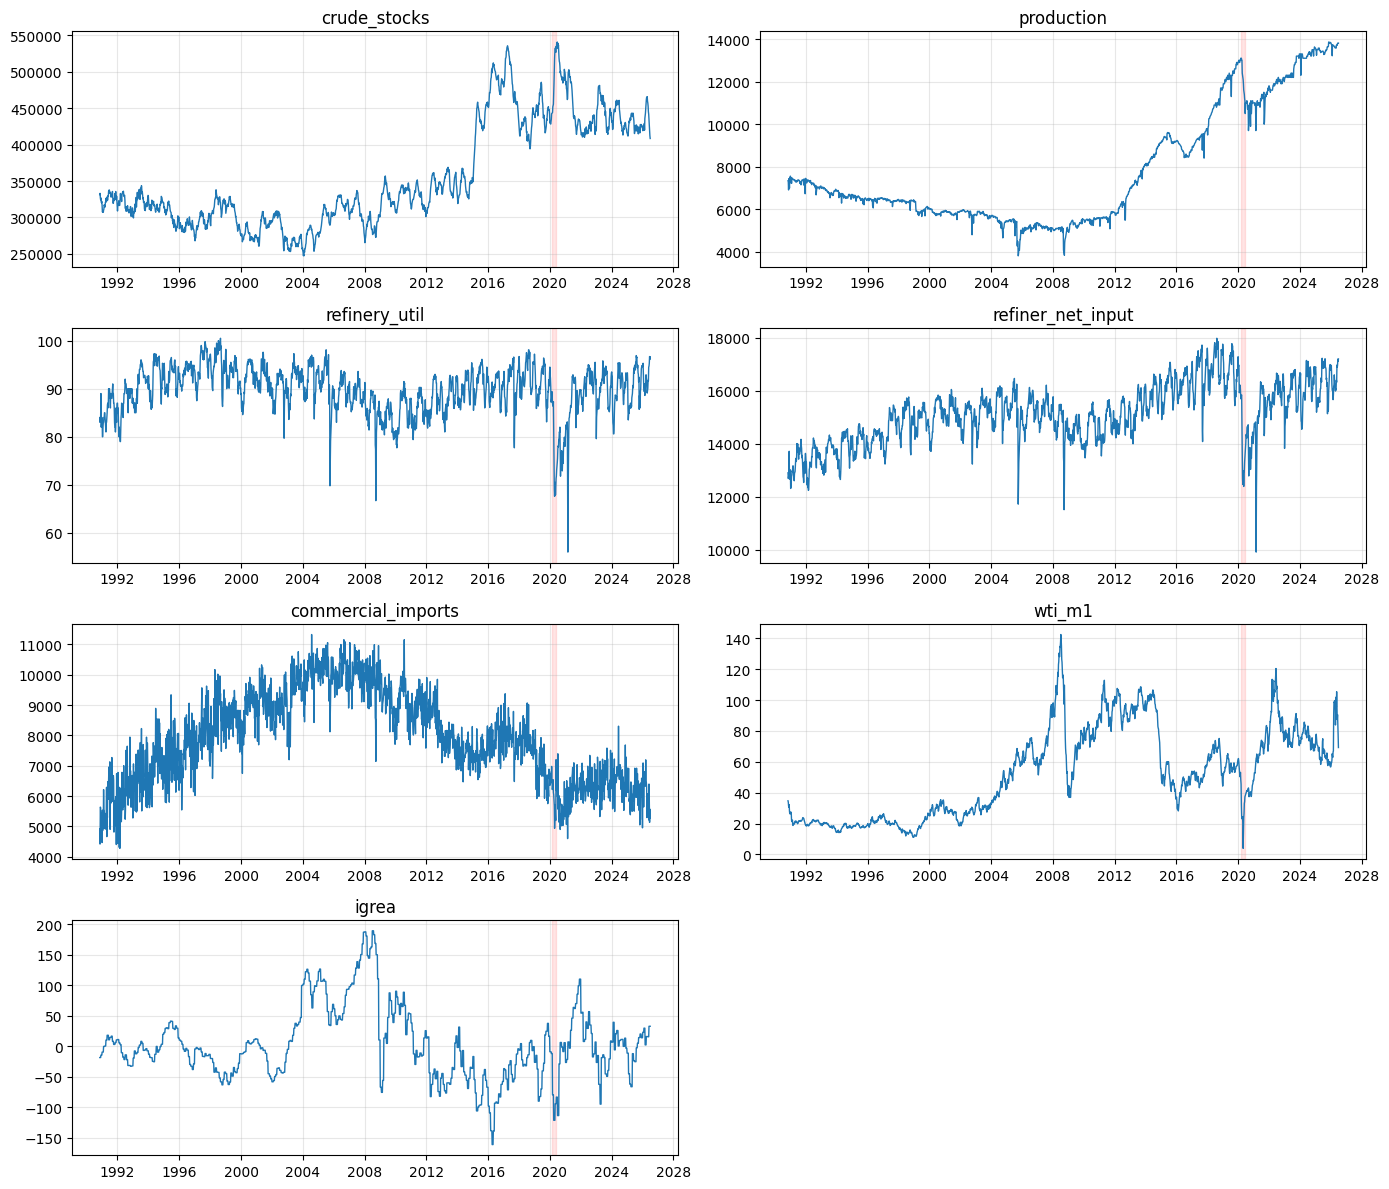

wti_m1 min: 3.92 on 2020-04-29


In [7]:
level_columns = ["crude_stocks", "production", "refinery_util", "refiner_net_input",
                 "commercial_imports", "wti_m1", "igrea"]

n_cols = 2
n_rows = int(np.ceil(len(level_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3 * n_rows))
axes = axes.flatten()

for ax, column in zip(axes, level_columns):
    ax.plot(ts.index, ts[column], linewidth=1)
    # Shaded band = April 2020 COVID shock, so a break there reads as a known event.
    ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-06-01"), color="red", alpha=0.10)
    ax.set_title(column)
    ax.grid(alpha=0.3)

# Hide the leftover empty axis (odd number of series).
for ax in axes[len(level_columns):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

print("wti_m1 min:", ts["wti_m1"].min(), "on", ts["wti_m1"].idxmin().date())

The fundamentals trend or shift regime rather than vary around a constant mean (production's
shale-era rise, the imports hump peaking in the mid-2000s, the step up in crude_stocks after
2015), so they are non-stationary in level and will enter the models in stationary form. April
2020 stands out as a shared outlier across refining, WTI and stocks, to be isolated before
estimation.


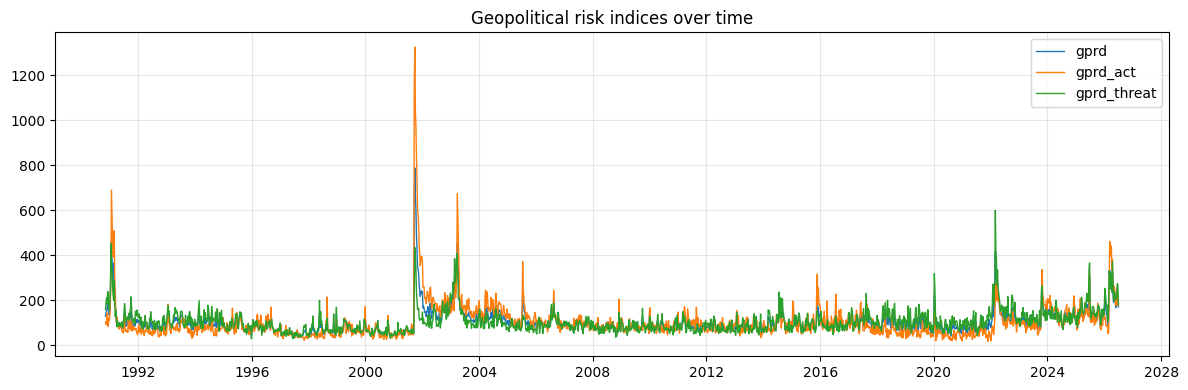

In [8]:
gpr_columns = ["gprd", "gprd_act", "gprd_threat"]

fig, ax = plt.subplots(figsize=(12, 4))
for column in gpr_columns:
    ax.plot(ts.index, ts[column], linewidth=1, label=column)
ax.legend()
ax.set_title("Geopolitical risk indices over time")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


All three GPR indices are a flat baseline broken by rare, event-driven spikes, so each is strongly
right-skewed with heavy tails. Most of the GPR variance sits in a handful of weeks, which
argues for a log transform before the linear VAR; tree models can take the raw index.


#### **3. Stationarity (ADF)**

Kilian & Murphy (2014) model stock changes, not levels, because inventory levels carry a
trend and are non-stationary. The Augmented Dickey-Fuller test checks this: its null
hypothesis is a unit root, so a p-value below 0.05 rejects non-stationarity. `crude_stocks`
in level is expected to be non-stationary and `target_stock_change` (its first difference)
stationary — which is what justifies using the change as the modelling target.

In [9]:
from statsmodels.tsa.stattools import adfuller

def run_adf(series, name):
    # ADF null hypothesis = unit root (non-stationary). p-value < 0.05 -> reject -> stationary.
    result = adfuller(series.dropna())
    verdict = "stationary" if result[1] < 0.05 else "non-stationary"
    print(f"{name}: ADF={result[0]:.3f}, p-value={result[1]:.4f} -> {verdict}")

run_adf(ts["crude_stocks"], "crude_stocks (level)")
run_adf(ts["target_stock_change"], "target_stock_change")

crude_stocks (level): ADF=-1.510, p-value=0.5287 -> non-stationary
target_stock_change: ADF=-9.787, p-value=0.0000 -> stationary


`crude_stocks` carries a unit root (p = 0.53) while `target_stock_change` is strongly
stationary (p ≈ 0). The differenced target is the right modelling variable: in ARIMA it needs
no further differencing (d = 0, as it is already a first difference of stocks), and it can
enter the VAR directly.

#### 4. **Seasonality of the target**

US crude stocks follow a known yearly pattern: refinery maintenance in spring and autumn, and
the summer driving season. The ACF/PACF and a seasonal decomposition document whether
`target_stock_change` carries a ~52-week cycle. An additive model is used because the target
is signed (it can be negative), which rules out a multiplicative decomposition. The result
decides whether seasonal dummies (or a SARIMA term) are needed later.

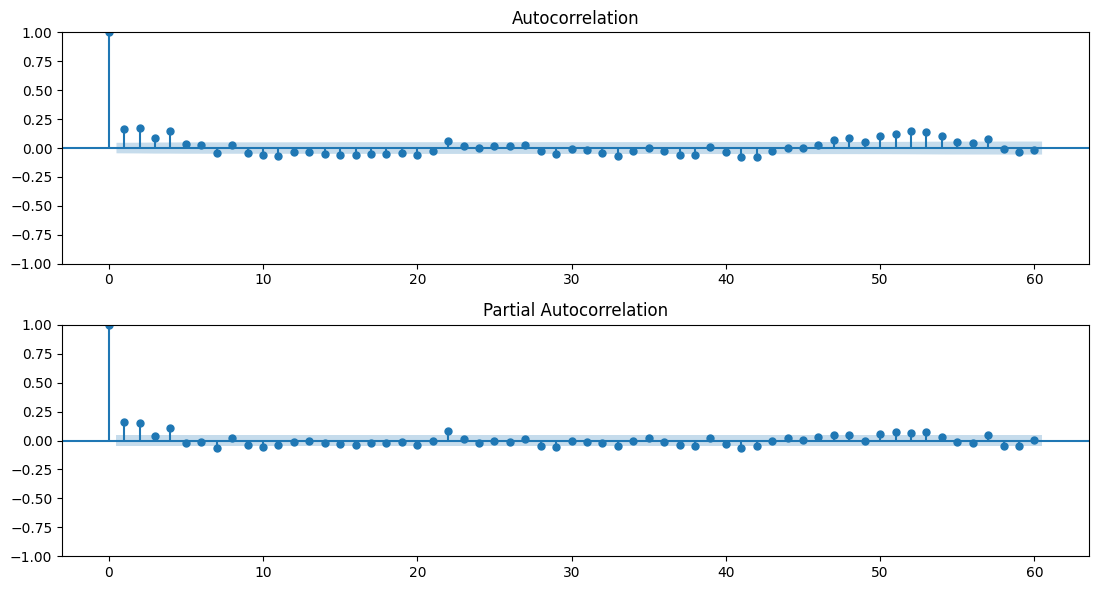

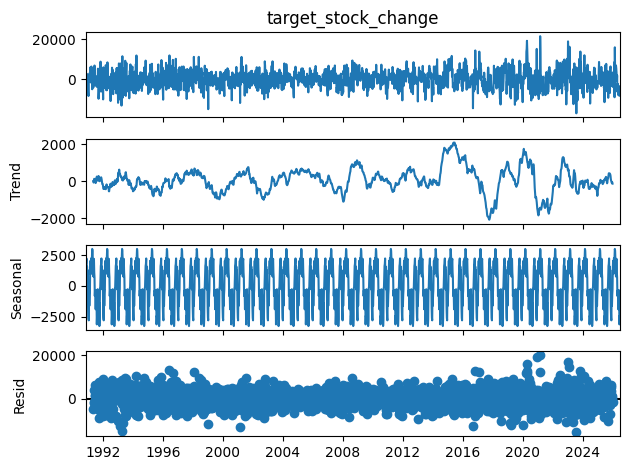

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

target = ts["target_stock_change"].dropna()

# 60 lags cover more than a year, so a yearly cycle shows up as a spike near lag 52.
fig, axes = plt.subplots(2, 1, figsize=(11, 6))
plot_acf(target, lags=60, ax=axes[0])
plot_pacf(target, lags=60, ax=axes[1], method="ywm")
plt.tight_layout()
plt.show()

# Additive decomposition (signed target rules out multiplicative); period=52 = yearly weekly cycle.
decomposition = seasonal_decompose(target, model="additive", period=52)
decomposition.plot()
plt.tight_layout()
plt.show()

`target_stock_change` has a clean annual cycle (seasonal amplitude ≈ ±3000, matching refinery
maintenance and the driving season) and modest short-term autocorrelation at lags 1-4. The
residual dominates the week-to-week variance, so seasonality alone explains little, but the
pattern is systematic: add seasonal dummies (or a SARIMA seasonal term) and allow low-order
AR/MA terms.

#### **5. GPR distribution**

Caldara & Iacoviello (2022) describe the GPR as strongly right-skewed, with sharp spikes
around geopolitical events. A linear model such as the VAR implicitly assumes roughly
symmetric shocks, so the skewness and kurtosis are quantified here: a large gap between mean
and median, positive skew and high kurtosis argue for a transformation (e.g. log) before the
index enters a linear model. Tree-based models are unaffected.

                   mean     median        std      skew       kurt
gprd         102.083867  90.233333  54.084237  4.514667  35.912548
gprd_act     101.285154  82.743333  84.141400  6.224576  62.160719
gprd_threat  104.679595  94.615000  50.981658  2.655902  12.559113


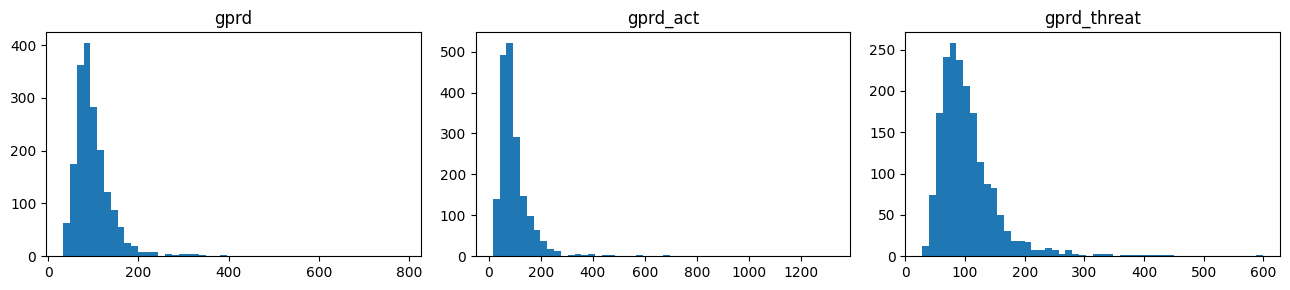

In [11]:
gpr_columns = ["gprd", "gprd_act", "gprd_threat"]

# Mean-vs-median gap, positive skew and high kurtosis together signal a spiky, asymmetric series.
summary = df[gpr_columns].agg(["mean", "median", "std", "skew", "kurt"]).T
print(summary)

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, column in zip(axes, gpr_columns):
    ax.hist(df[column].dropna(), bins=50)
    ax.set_title(column)
plt.tight_layout()
plt.show()


All three indices are right-skewed (skew 2.7 to 6.2) and fat-tailed (excess kurtosis 13 to 62),
with mean above median — `gprd_act` the most extreme. A log transform is warranted before the
linear VAR, so that a few spikes do not dominate; the tree models can take the raw index.


#### 6. **Correlation between predictors**

The VAR is sensitive to collinearity. Two blocks matter here. The EIA fundamentals
(`production`, `refinery_util`, `refiner_net_input`, `commercial_imports`) move together with
the refining cycle. The GPR trio (`gprd`, `gprd_act`, `gprd_threat`) is correlated by
construction, since the overall index is built from acts and threats. Strongly correlated
pairs are candidates to drop or combine before estimation.

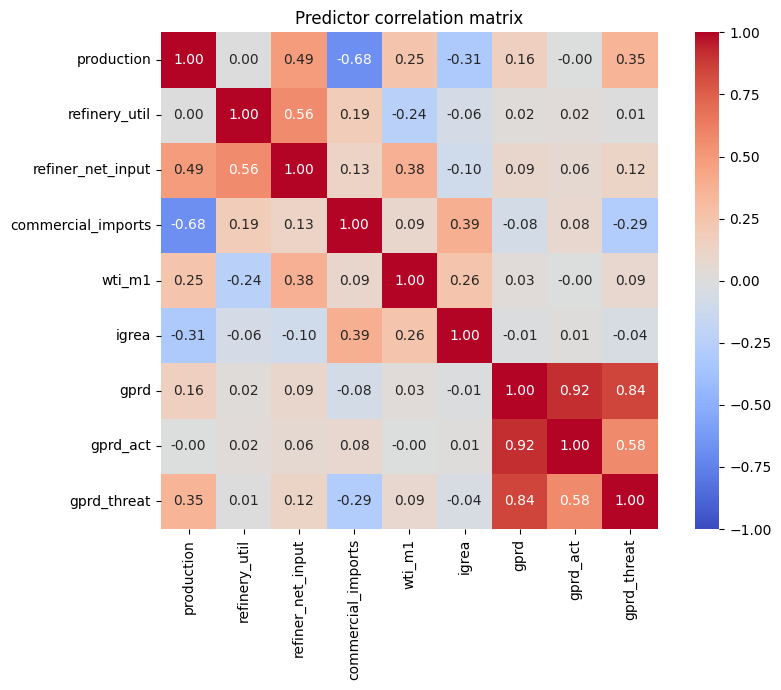

In [12]:
import seaborn as sns

predictor_columns = ["production", "refinery_util", "refiner_net_input", "commercial_imports",
                     "wti_m1", "igrea", "gprd", "gprd_act", "gprd_threat"]

correlation = df[predictor_columns].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Predictor correlation matrix")
plt.tight_layout()
plt.show()

The GPR trio is highly collinear: `gprd` correlates 0.92 with `gprd_act` and 0.84 with
`gprd_threat`, so only one GPR representation should enter the VAR — either the composite or
the two sub-indices, never all three. Among the fundamentals the only strong pair is
`production` vs `commercial_imports` (-0.68, the shale-era substitution); `refinery_util` and
`refiner_net_input` are moderately linked (0.56). These are manageable but worth a VIF check
before the VAR.


#### **7. Lagged cross-correlation: GPR vs targe**

To get a first sense of the horizon at which geopolitical risk might move stocks, the target
at week t is correlated with each GPR series at week t − k, for k = 1 to 8 weeks. A positive
lag means the GPR leads the target by k weeks. This is only a linear, bivariate hint — it
ignores the other predictors — but it points to where the formal models should look.

    gprd  gprd_act  gprd_threat
1  0.012     0.026       -0.014
2  0.004     0.021       -0.019
3  0.006     0.021       -0.017
4  0.016     0.020        0.003
5  0.015     0.021       -0.000
6  0.004     0.009       -0.006
7 -0.013    -0.004       -0.028
8 -0.007    -0.007       -0.015


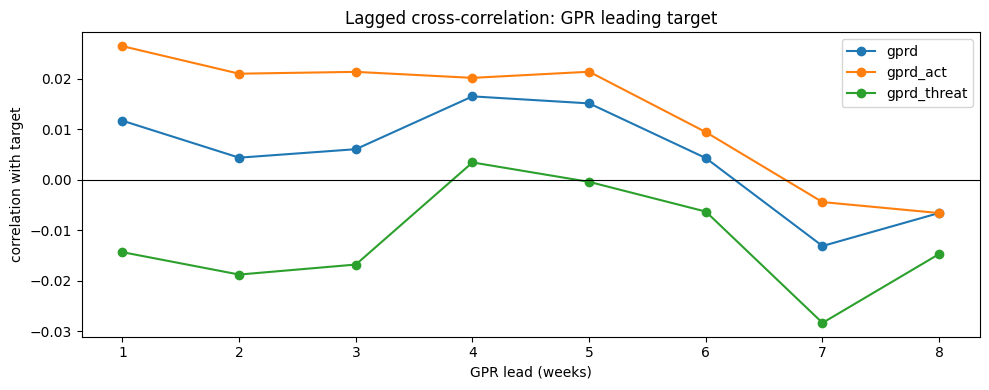

In [13]:
def lagged_correlations(target_series, predictor_series, max_lag):
    # corr(target_t, predictor_{t-lag}): the predictor leads the target by 'lag' weeks.
    return {lag: target_series.corr(predictor_series.shift(lag)) for lag in range(1, max_lag + 1)}

max_lag = 8
lagged = pd.DataFrame({column: lagged_correlations(ts["target_stock_change"], ts[column], max_lag)
                       for column in gpr_columns})
print(lagged.round(3))

lagged.plot(marker="o", figsize=(10, 4))
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("GPR lead (weeks)")
plt.ylabel("correlation with target")
plt.title("Lagged cross-correlation: GPR leading target")
plt.tight_layout()
plt.show()

At the bivariate level the GPR–target correlation is negligible at every lag (|r| < 0.03), and
no horizon stands out. Geopolitical risk does not linearly predict weekly stock changes on its
own, so any contribution has to come through the multivariate VAR (a partial effect, once the
fundamentals are controlled for) or the non-linear tree models. Expectations for a standalone
GPR signal should stay modest.


#### **Robustness: lagged cross-correlation on log(GPR)**

The correlation above used the raw GPR, which is heavily right-skewed. A handful of extreme
spikes can dominate a Pearson correlation and hide a relationship that holds over the normal
range. The same lagged cross-correlation is recomputed on log(GPR), which compresses the
spikes, before any conclusion is drawn.

   log_gprd  log_gprd_act  log_gprd_threat
1     0.002         0.015           -0.013
2    -0.011         0.015           -0.033
3    -0.003         0.028           -0.027
4     0.009         0.025           -0.005
5     0.005         0.023           -0.011
6     0.002         0.027           -0.014
7    -0.007         0.009           -0.021
8     0.001         0.001           -0.007


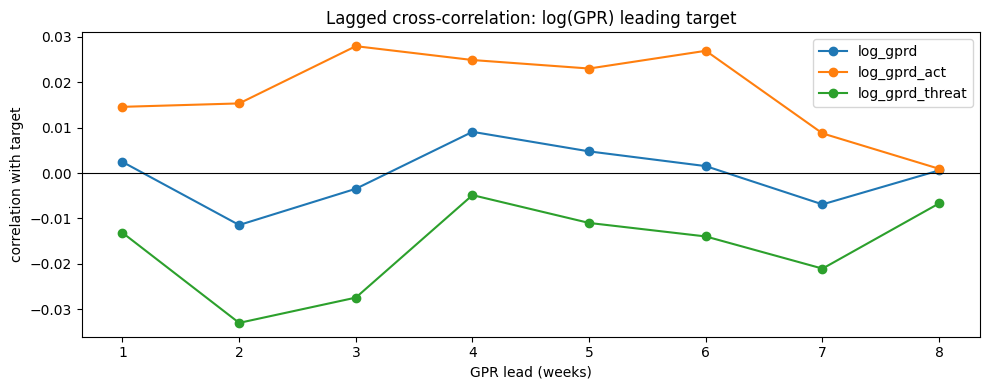

In [14]:
# log compresses the extreme GPR spikes so the correlation is not driven by a few weeks.
# GPR is a strictly positive index, so the log is well defined.
log_gpr = np.log(ts[gpr_columns]).add_prefix("log_")

max_lag = 8
lagged_log = pd.DataFrame({column: lagged_correlations(ts["target_stock_change"], log_gpr[column], max_lag)
                           for column in log_gpr.columns})
print(lagged_log.round(3))

lagged_log.plot(marker="o", figsize=(10, 4))
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("GPR lead (weeks)")
plt.ylabel("correlation with target")
plt.title("Lagged cross-correlation: log(GPR) leading target")
plt.tight_layout()
plt.show()


Compressing the spikes leaves the picture unchanged: correlations stay within ±0.03 at every
lag, below the ~0.05 significance threshold for this sample size. The near-zero bivariate signal
was not a skew artefact, so the section 7 conclusion holds — GPR shows no standalone linear lead
on weekly stock changes, and any effect must be sought in the multivariate or non-linear models.


#### **EDA — Conclusion**

The exploratory analysis validates the dataset and shapes the modelling
choices that follow.

**Data integrity.** The panel is clean: 1861 weekly observations from November
1990 onward, no missing values, no duplicate dates, and a strict 7-day gap
between every consecutive EIA release. The look-ahead precautions taken when
aligning the GPR window, the IGREA forward-fill and the publication calendar
hold up.

**Stationarity.** `crude_stocks` in level carries a unit root (ADF p = 0.53)
while its first difference `target_stock_change` is strongly stationary
(ADF p ≈ 0). This confirms the modelling target must be the change, not the
level, in line with Kilian & Murphy (2014), who model inventory changes for
the same reason
(https://onlinelibrary.wiley.com/doi/abs/10.1002/jae.2322).
In ARIMA the target needs no further differencing (d = 0); it can enter the
VAR directly.

**Seasonality.** `target_stock_change` shows a clean annual cycle (seasonal
amplitude ≈ ±3000), consistent with refinery maintenance in spring and autumn
and the summer driving season, plus modest short-term autocorrelation at lags
1–4. This mirrors Kilian & Murphy (2014), who remove seasonal variation with
seasonal dummies in their VAR
(https://onlinelibrary.wiley.com/doi/abs/10.1002/jae.2322). Seasonal dummies
(or a SARIMA seasonal term) and low-order AR/MA terms are therefore warranted.

**GPR distribution.** All three geopolitical indices are strongly right-skewed
(skew 2.7 to 6.2) and fat-tailed (excess kurtosis 13 to 62), as described by
Caldara & Iacoviello (2022)
(https://www.aeaweb.org/articles?id=10.1257/aer.20191823). A log transform is
applied before the linear VAR so that a handful of spikes do not dominate;
the tree-based models (Random Forest, XGBoost) can take the raw index.

**Collinearity.** The GPR trio is collinear by construction (`gprd` correlates
0.92 with `gprd_act` and 0.84 with `gprd_threat`), since the composite index is
built from acts and threats. Only one GPR representation may enter the VAR:
either the composite (H1) or the two sub-indices (H1a), never all three. Among
the fundamentals, only `production` vs `commercial_imports` (-0.68, shale-era
substitution) stands out; a VIF check is advisable before the VAR.

**Key finding — no standalone linear GPR signal.** The lagged cross-correlation
between each GPR series and the target is negligible at every horizon
(|r| < 0.03), and the log transform leaves this unchanged, so the near-zero
signal is not a skew artefact. Geopolitical risk does not, on its own, linearly
lead weekly stock changes.

This does not invalidate H1. The precautionary storage mechanism it tests is
conditional on the fundamentals, not marginal: it is expected to appear once
production, refining and imports are controlled for (Kilian, 2009,
https://www.aeaweb.org/articles?id=10.1257/aer.99.3.1053; Kilian, Plante &
Richter, 2024,
https://www.dallasfed.org/-/media/documents/research/papers/2024/wp2403.pdf),
or through non-linear, threshold-type effects that a Pearson correlation cannot
capture but tree models can (Ma, Wang & Wang, 2026,
https://link.springer.com/article/10.1186/s40854-025-00837-1). Any GPR
contribution must therefore be sought in the multivariate VAR (a partial effect)
or in the non-linear models, and expectations for a standalone signal should
stay modest.

**Implication for the modelling stage.** The sequence is: (1) an ARIMA baseline
on the seasonal, stationary target; (2) a VAR in the spirit of Kilian & Murphy
(2014,
https://onlinelibrary.wiley.com/doi/abs/10.1002/jae.2322) to test the
conditional linear effect of GPR; (3) Random Forest and XGBoost for non-linear
effects. Each model is estimated with and without the GPR block, and the
incremental value of geopolitical risk is assessed out-of-sample by forecast
error reduction and directional accuracy. Whether the GPR adds information or
not, the incrementality test remains the core contribution.

### **Modelling - ARIMA Baseline**

The first model is a univariate ARIMA on `target_stock_change`: it knows only the past of the
target, with no explanatory variables. It is the minimal comparison point before fundamentals
and GPR are introduced, and plays the standard autoregressive benchmark role in the
oil-forecasting literature (Behmiri & Pires Manso, 2013).

**Evaluation framework**

These rules are shared by every model in the project.

- **Chronological split, never random.** The test period is the last part of the sample, so the
  model only ever sees past data. A random split would break the time order and leak the future.
- **Walk-forward, one step ahead.** Predictions are produced by an expanding window: at each test
  week the model is refit on all prior data and forecasts the next week only.
- **Out-of-sample only.** Every metric is computed on the test period.
- **Metrics.** RMSE and MAE for the forecast error, plus directional accuracy — the share of
  weeks where the predicted sign of the change is correct. Direction matters as much as RMSE
  here, since the sign is what would drive a trading signal.
- **No-change benchmark.** The target is already a weekly change, so the no-change forecast (a
  random walk on the stock level, Baumeister & Kilian 2015) is a constant zero: stocks do not
  move this week. Its directional accuracy is ~0 by construction, so a coin flip (50%) is the
  reference for directional skill.

In [15]:
import numpy as np
import pandas as pd

df = pd.read_csv("dataset/H1_dataset_weekly.csv", parse_dates=["publication_date", "week_ended"])
target = df.set_index("publication_date")["target_stock_change"]

# Chronological split: first 80% trains, last 20% tests. No shuffling, so the test period is
# strictly in the future relative to training.
split_index = int(len(target) * 0.8)
train = target.iloc[:split_index]
test = target.iloc[split_index:]

print("Train:", train.index.min().date(), "->", train.index.max().date(), f"({len(train)} obs)")
print("Test :", test.index.min().date(), "->", test.index.max().date(), f"({len(test)} obs)")

def rmse(actual, predicted):
    return float(np.sqrt(np.mean((actual - predicted) ** 2)))

def mae(actual, predicted):
    return float(np.mean(np.abs(actual - predicted)))

def directional_accuracy(actual, predicted):
    # Share of weeks where the predicted sign matches the realised sign of the change.
    return float(np.mean(np.sign(actual) == np.sign(predicted)))

def evaluate(actual, predicted):
    # One row of out-of-sample metrics for a set of predictions.
    return {"RMSE": rmse(actual, predicted),
            "MAE": mae(actual, predicted),
            "Directional accuracy": directional_accuracy(actual, predicted)}

# No-change benchmark on a change target = predict zero change every week.
no_change_prediction = pd.Series(0.0, index=test.index)
benchmark_metrics = evaluate(test, no_change_prediction)
print("\nNo-change benchmark:", {key: round(value, 3) for key, value in benchmark_metrics.items()})

Train: 1990-11-07 -> 2019-05-08 (1488 obs)
Test : 2019-05-15 -> 2026-07-01 (373 obs)

No-change benchmark: {'RMSE': 5609.228, 'MAE': 4343.483, 'Directional accuracy': 0.0}


#### **Benchmark to beat**


On the test period (May 2019 – July 2026, 373 weeks) the no-change benchmark sets the bar: RMSE
≈ 5609 and MAE ≈ 4343 (thousand barrels), with 50% as the directional reference (its own 0% is a
construction artefact of the zero forecast). Any model must improve on these to be useful. The
window spans the COVID shock, which inflates the target's RMS and is revisited in the April 2020
robustness step.

#### **Order selection**


The target is stationary (EDA), so no differencing is needed: d = 0. The EDA autocorrelations
were significant up to about lag 4, so the search stays on small orders. Each ARIMA(p, 0, q) on a
0-4 grid is fit on the training period and scored by AIC; the lowest-AIC order is kept. AIC trades
fit against complexity, which guards against overfitting a spuriously large order.

In [16]:
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")  # silence ARIMA convergence chatter on some orders

# d = 0 (target already stationary). Small p, q grid, guided by the EDA ACF/PACF (significant up
# to ~lag 4). AIC balances fit and complexity.
order_scores = []
for p in range(5):
    for q in range(5):
        try:
            fitted = ARIMA(train, order=(p, 0, q)).fit()
            order_scores.append({"order": (p, 0, q), "AIC": fitted.aic, "BIC": fitted.bic})
        except Exception:
            continue

order_scores = pd.DataFrame(order_scores).sort_values("AIC").reset_index(drop=True)
print(order_scores.head(10))

best_order = order_scores.loc[0, "order"]
print("\nSelected order (min AIC):", best_order)


       order           AIC           BIC
0  (3, 0, 3)  28951.256510  28993.698016
1  (4, 0, 4)  28953.593955  29006.645838
2  (2, 0, 4)  28957.244082  28999.685588
3  (4, 0, 1)  28957.389925  28994.526243
4  (4, 0, 2)  28957.966489  29000.407995
5  (2, 0, 2)  28958.083208  28989.914338
6  (4, 0, 3)  28958.814875  29006.561569
7  (4, 0, 0)  28959.202092  28991.033221
8  (3, 0, 4)  28959.471007  29007.217701
9  (2, 0, 3)  28959.813308  28996.949625

Selected order (min AIC): (3, 0, 3)


AIC points to (3,0,3), but the scores are nearly identical across very different orders (all
within ~10 AIC points), so the in-sample criteria barely discriminate. BIC, which penalises
complexity more, prefers the parsimonious (2,0,2). For an out-of-sample baseline that is refit at
every walk-forward step, fewer parameters is the safer choice, so (2,0,2) is retained; the larger
(3,0,3) can be re-checked on the test metrics if the baseline underperforms.


#### **Out-of-sample forecast**

The ARIMA is evaluated by walk-forward: at each test week it is refit on all prior data and
forecasts the next week only, then the realised value is appended before the next step. This
reproduces real-time forecasting and keeps the evaluation strictly out-of-sample. The three
metrics are placed next to the no-change benchmark.


In [17]:
arima_order = (2, 0, 2)  # parsimonious (BIC) choice; see the order-selection note above

# Expanding-window walk-forward: refit on all data up to each test week, forecast one step, then
# append the realised value before moving on. Mimics real-time forecasting with no leak.
history = list(train)
arima_predictions = []
for actual_value in test:
    fitted = ARIMA(history, order=arima_order).fit()
    next_forecast = float(np.asarray(fitted.forecast(steps=1))[0])
    arima_predictions.append(next_forecast)
    history.append(actual_value)

arima_predictions = pd.Series(arima_predictions, index=test.index)

arima_metrics = evaluate(test, arima_predictions)
results = pd.DataFrame([
    {"model": "No-change", **benchmark_metrics},
    {"model": f"ARIMA{arima_order}", **arima_metrics},
])
print(results.round(3))


            model      RMSE       MAE  Directional accuracy
0       No-change  5609.228  4343.483                 0.000
1  ARIMA(2, 0, 2)  5365.241  4139.580                 0.587


ARIMA(2,0,2) beats the no-change benchmark: RMSE 5365 vs 5609 (−4.3%), MAE 4140 vs 4343 (−4.7%),
and 58.7% directional accuracy against a 50% chance level. The error gain is modest, but the
directional edge is the meaningful result for the trading objective. This is the baseline that
the fundamentals and GPR now have to beat.


#### **Seasonal variant (SARIMA)**

The EDA showed a yearly (~52-week) cycle. To isolate its contribution, the non-seasonal ARIMA and
the SARIMA are compared under an identical protocol: same (2,0,2) structure, parameters estimated
once on the training set (a full refit at every step is impractical for a 52-week period), then the
fitted state extended over the test for one-step-ahead forecasts. The two differ only in the
seasonal term, so any gap is the seasonal contribution. The term is kept only if it beats the
non-seasonal model out of sample.



In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def fixed_param_forecast(seasonal_order):
    # Fit once on train, then extend over the test for one-step-ahead forecasts. Identical settings
    # across calls, so the only difference is the seasonal term -> a matched comparison.
    fitted = SARIMAX(np.asarray(train), order=(2, 0, 2), seasonal_order=seasonal_order,
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    extended = fitted.extend(np.asarray(test))
    return pd.Series(np.asarray(extended.get_prediction().predicted_mean), index=test.index)

arima_fixed = fixed_param_forecast((0, 0, 0, 0))          # no seasonal term
sarima_predictions = fixed_param_forecast((1, 0, 1, 52))  # yearly seasonal term (carried forward)

seasonal_comparison = pd.DataFrame([
    {"model": "No-change", **benchmark_metrics},
    {"model": "ARIMA(2,0,2), fixed params", **evaluate(test, arima_fixed)},
    {"model": "SARIMA(2,0,2)(1,0,1,52), fixed params", **evaluate(test, sarima_predictions)},
])
print(seasonal_comparison.round(3))

                                   model      RMSE       MAE  \
0                              No-change  5609.228  4343.483   
1             ARIMA(2,0,2), fixed params  5365.376  4139.640   
2  SARIMA(2,0,2)(1,0,1,52), fixed params  5304.497  4098.705   

   Directional accuracy  
0                 0.000  
1                 0.582  
2                 0.627  


Under an identical fixed-parameter protocol the seasonal term improves every out-of-sample metric:
RMSE 5304 vs 5365, MAE 4099 vs 4140, and directional accuracy 62.7% vs 58.2%. The non-seasonal
ARIMA scores the same whether refit each step or fixed (5365 either way), so the protocol is not
what drives the gap — the yearly cycle carries genuine signal. SARIMA(2,0,2)(1,0,1,52) is kept as
the ARIMA-family baseline; the directional gain (+4.5 points) is the part that matters most for the
trading objective.



#### **April 2020 robustness**



The EDA flagged April 2020 as an extreme, unpredictable COVID shock (record crude builds, WTI
near zero). The episode is kept in the data — removing it would distort estimation — but its
weeks are dropped from the *test* metrics as a robustness check, to confirm the model ranking is
not an artefact of a single unforecastable period

In [19]:
# Recompute the metrics with the COVID weeks removed from the test set. Same predictions, smaller
# evaluation window, so any change reflects only that episode's weight in the error.
covid_start, covid_end = pd.Timestamp("2020-03-01"), pd.Timestamp("2020-06-01")
keep = (test.index < covid_start) | (test.index > covid_end)

predictions = {
    "No-change": no_change_prediction,
    "ARIMA(2,0,2)": arima_predictions,
    "SARIMA(2,0,2)(1,0,1,52)": sarima_predictions,
}
results_ex_covid = pd.DataFrame([
    {"model": name, **evaluate(test[keep], prediction[keep])}
    for name, prediction in predictions.items()
])
print("Excluded weeks:", int((~keep).sum()))
print(results_ex_covid.round(3))


Excluded weeks: 13
                     model      RMSE       MAE  Directional accuracy
0                No-change  5390.858  4215.494                 0.000
1             ARIMA(2,0,2)  5241.856  4063.218                 0.578
2  SARIMA(2,0,2)(1,0,1,52)  5136.381  3994.054                 0.622


Dropping the 13 COVID weeks lowers each RMSE only modestly (SARIMA 5304 → 5136, about 3%), so the
episode inflates the error without dominating it, and the ranking is unchanged: no-change < ARIMA
< SARIMA, with SARIMA's edge intact on all three metrics. The baseline conclusion is robust to the
shock, so the episode is kept in the sample without a dedicated dummy.


#### **Out-of-sample fit**




Realised weekly changes against the SARIMA one-step-ahead forecast over the test period, with the
COVID window shaded. The forecast amplitude is expectedly small next to the raw swings — weekly
stock changes are largely noise — so the model's value lies in the marginal error gain and the
directional edge rather than in tracking every move.

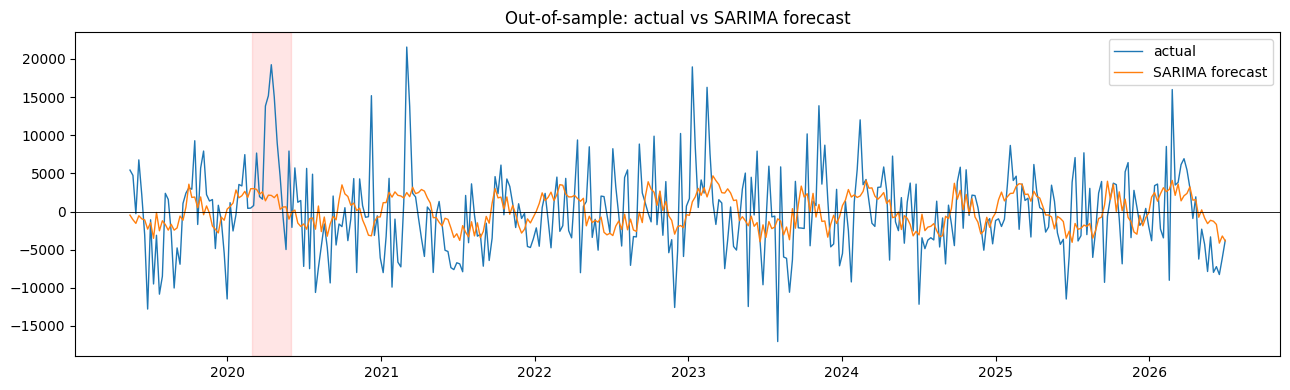

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test.index, test.values, label="actual", linewidth=1)
ax.plot(sarima_predictions.index, sarima_predictions.values, label="SARIMA forecast", linewidth=1)
ax.axvspan(covid_start, covid_end, color="red", alpha=0.10)
ax.axhline(0, color="black", linewidth=0.6)
ax.legend()
ax.set_title("Out-of-sample: actual vs SARIMA forecast")
plt.tight_layout()
plt.show()


The forecast is a low-amplitude, mean-reverting line while the realised changes swing several
times wider: the model captures the average tendency and the sign more often than not, but not
the size of individual weeks. This matches the metrics — the value is a small error gain plus the
directional edge — and sets a realistic ceiling for what fundamentals and GPR can add.


In [21]:
forecasts = pd.DataFrame({
    "actual": test,
    "no_change": no_change_prediction,
    "arima": arima_predictions,
    "sarima": sarima_predictions,
})
forecasts.to_csv("dataset/H1_forecasts_arima.csv")
print(forecasts.shape)
forecasts.head()


(373, 4)


,actual,no_change,arima,sarima
publication_date,,,,
2019-05-15,5431.0,0.0,1209.603766,-474.725848
2019-05-22,4740.0,0.0,678.494961,-1070.630893
2019-05-29,-282.0,0.0,1874.771024,-1554.364010
2019-06-05,6771.0,0.0,644.342401,-554.427465
2019-06-12,2206.0,0.0,1479.935832,-953.753621


#### **Conclusion**

**Baseline set.** A parsimonious ARIMA(2,0,2), selected by BIC on the stationary
target, already beats the no-change benchmark out of sample: RMSE 5365 vs 5609
(−4.3%), MAE 4140 vs 4343 (−4.7%), and 58.7% directional accuracy against a 50%
chance level. The error gain is modest, but the directional edge is the meaningful
result for the trading objective, since the sign of the change is what would
trigger a signal.

**Seasonality confirmed.** Adding a yearly seasonal term (SARIMA(2,0,2)(1,0,1,52))
improves every out-of-sample metric (RMSE 5304 vs 5365, MAE 4099 vs 4140,
directional accuracy 62.7% vs 58.2%). The comparison is made under an identical
fixed-parameter protocol, and the non-seasonal ARIMA scores the same whether refit
at each step or fixed (5365 either way), so the gap reflects the seasonal term, not
the estimation scheme. This confirms the annual cycle documented in the EDA
(refinery maintenance, driving season) carries real signal, so
SARIMA(2,0,2)(1,0,1,52) is retained as the ARIMA-family baseline; the directional
gain (+4.5 points) is the part that matters most for the trading objective.

**Robust to COVID.** Removing the 13 COVID weeks (March–June 2020) lowers each RMSE
only modestly (SARIMA 5304 → 5136, about 3%) and leaves the ranking unchanged
(no-change < ARIMA < SARIMA). The episode inflates the error without dominating it,
so it is kept in the sample without a dedicated dummy, and the baseline conclusion
does not rest on how one extreme quarter is handled.

**What the baseline says about the ceiling.** The actual-vs-forecast plot makes the
honest limit visible: the forecast is a low-amplitude, mean-reverting line while
realised weekly changes swing several times wider. Weekly stock changes are largely
noise, so no model on this target should be expected to track individual weeks. The
realistic value to look for is a small error reduction plus a directional edge, not
a high R². This sets a sober ceiling for what the fundamentals and GPR can add.

**Implications for the next stage.** The SARIMA baseline is now the number to beat.
Two points follow directly.

First, the univariate model captures the target's own memory and seasonality but
nothing about market fundamentals. The VAR is the natural next step: it lets
production, refining, imports and price interact with stocks, in the spirit of the
structural oil-market system of Kilian & Murphy (2014)
(https://onlinelibrary.wiley.com/doi/abs/10.1002/jae.2322), and it is where the
conditional (partial) effect of GPR can first appear, since the EDA ruled out any
standalone linear GPR signal.

Second, because the directional metric is where the baseline adds the most, it
should stay the primary yardstick for every later model, alongside RMSE. A model
that lowers RMSE without improving direction would be of limited use for the trading
objective; the reverse is more valuable.

The incremental test of H1 remains the core question: each later model is run with
and without the GPR block, and the geopolitical variables earn their place only if
they improve out-of-sample performance over this baseline, following the
forecast-combination and real-time evaluation logic of Baumeister & Kilian (2015)
(https://www.tandfonline.com/doi/abs/10.1080/07350015.2014.949342).


### **Modelling - VAR**

The VAR is the core of the H1 test: it lets stocks interact with the fundamentals (production,
refining, imports, price) and the macro block, in the spirit of the structural oil-market system
of Kilian & Murphy (2014). Two specifications are compared — without and with the GPR block — and
the out-of-sample gap between them measures the incremental value of geopolitical risk, which the
EDA showed has no standalone linear effect.


A VAR requires **stationary inputs**. The target is already stationary (EDA), but the fundamentals and
price are likely trending. Each variable is ADF-tested and differenced once if it carries a unit
root; the target is kept as is. What was differenced is documented, since it changes the reading
of each equation.


In [22]:
from statsmodels.tsa.stattools import adfuller

# Target first (its equation is the one we forecast), then fundamentals and macro.
var_columns = ["target_stock_change", "production", "refinery_util", "refiner_net_input",
               "commercial_imports", "wti_m1", "igrea"]
var_levels = df.set_index("publication_date")[var_columns]

# ADF on each series: p >= 0.05 means a unit root, so the series is differenced once.
stationary_data = pd.DataFrame(index=var_levels.index)
differenced = []
for column in var_columns:
    pvalue = adfuller(var_levels[column].dropna())[1]
    if pvalue < 0.05:
        stationary_data[column] = var_levels[column]
    else:
        stationary_data[column] = var_levels[column].diff()
        differenced.append(column)

stationary_data = stationary_data.dropna()
print("Differenced:", differenced)
print("Kept as level/stationary:", [c for c in var_columns if c not in differenced])
print("Shape:", stationary_data.shape)


Differenced: ['production', 'commercial_imports', 'wti_m1']
Kept as level/stationary: ['target_stock_change', 'refinery_util', 'refiner_net_input', 'igrea']
Shape: (1860, 7)


ADF differences the three trending series (production, commercial_imports, wti_m1) and keeps
target_stock_change, refinery_util, refiner_net_input and igrea. refiner_net_input is kept despite
a visible upward trend because ADF rejects a unit root at 5% — the test is the arbiter, so the VAR
mixes changes and levels, all stationary by the test.


#### **Multicollinearity (VIF)**

The EDA flagged production and commercial_imports as correlated (−0.68). Before estimating the VAR,
the variance inflation factor quantifies how much each variable is explained by the others. A
constant is included so the VIFs are computed correctly; a value above ~5 signals redundancy worth
noting, though a VAR can still be estimated with mild collinearity.


In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# VIF needs a constant in the design matrix to be computed correctly.
vif_input = add_constant(stationary_data)
vif_table = pd.DataFrame({
    "variable": vif_input.columns,
    "VIF": [variance_inflation_factor(vif_input.values, i) for i in range(vif_input.shape[1])],
})
print(vif_table[vif_table["variable"] != "const"].round(2))


              variable   VIF
1  target_stock_change  1.23
2           production  1.02
3        refinery_util  1.52
4    refiner_net_input  1.48
5   commercial_imports  1.13
6               wti_m1  1.01
7                igrea  1.02


All VIFs are near 1 (max 1.52), far below any threshold: no multicollinearity concern. Differencing
production and commercial_imports removed the level correlation the EDA had flagged, so every
variable can enter the VAR together.


#### **GPR block and seasonal dummies**


The GPR enters log-transformed (EDA: strong right-skew) and is ADF-tested like the other inputs;
being mean-reverting, it should be stationary in log. Seasonality is handled with month-of-year
dummies as exogenous regressors — the weekly cycle documented in the EDA, captured with far fewer
parameters than 52 weekly dummies, following the monthly seasonal dummies of Kilian & Murphy
(2014). One month is dropped as the reference to avoid collinearity with the VAR constant.

In [24]:
# Log-GPR, ADF-checked like the other inputs.
log_gpr = np.log(df.set_index("publication_date")[["gprd", "gprd_act", "gprd_threat"]])
for column in log_gpr.columns:
    pvalue = adfuller(log_gpr[column].dropna())[1]
    print(f"{column}: ADF p-value={pvalue:.4f} -> {'stationary' if pvalue < 0.05 else 'non-stationary'}")

# Month-of-year dummies as exogenous seasonal regressors, aligned to the stationary sample.
seasonal_dummies = pd.get_dummies(stationary_data.index.month, prefix="month", drop_first=True).astype(float)
seasonal_dummies.index = stationary_data.index
print("\nSeasonal dummies:", seasonal_dummies.shape)


gprd: ADF p-value=0.0000 -> stationary
gprd_act: ADF p-value=0.0008 -> stationary
gprd_threat: ADF p-value=0.0000 -> stationary

Seasonal dummies: (1860, 11)


All three log-GPR series are stationary (ADF p ≤ 0.001), so the GPR block enters in log with no
differencing, unlike the fundamentals. The 11 month dummies are ready as exogenous seasonal
regressors.


#### **Lag selection**




The VAR lag order is chosen by information criteria on the training period only (never the test),
with the seasonal dummies included as exogenous regressors. AIC favours fit, BIC/HQIC favour
parsimony; since the model is refit at every walk-forward step, a parsimonious order is preferable
to limit estimation noise.

In [25]:
from statsmodels.tsa.api import VAR

# Select the order on the training period only, restricted set, with the seasonal dummies as exog.
var_train = stationary_data[stationary_data.index < test.index[0]]
dummies_train = seasonal_dummies[seasonal_dummies.index < test.index[0]]

order_selection = VAR(var_train, exog=dummies_train).select_order(maxlags=8)
print(order_selection.summary())


 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       65.13       65.43   1.921e+28       65.24
1       53.83       54.30   2.381e+23       54.00
2       53.41      54.07*   1.574e+23       53.66
3       53.26       54.08   1.346e+23       53.57
4       53.16       54.17   1.226e+23      53.54*
5       53.13       54.31   1.187e+23       53.57
6       53.10       54.45   1.149e+23       53.60
7       53.11       54.64   1.159e+23       53.68
8      53.09*       54.79  1.136e+23*       53.72
-------------------------------------------------


AIC and FPE keep improving out to lag 8, but BIC selects 2 and HQIC 4 — the usual pattern where AIC
over-parameterises. With seven endogenous variables, lag 8 means about 68 coefficients per equation
refit at every step; the parsimonious BIC order (p = 2) is the robust choice for out-of-sample
forecasting, so the VAR uses 2 lags.

#### **Restricted VAR — out-of-sample forecast**

The restricted VAR (target plus fundamentals and macro, no GPR) is forecast by the same walk-forward
as the ARIMA: at each test week it is refit on all prior data, forecasts one step, and only the
target equation is kept. The seasonal dummies for the next week are known, so they are passed as
exogenous inputs. This function is reused for the augmented specifications.

In [26]:
def var_target_forecast(endog, exog, test_index, lags):
    # Walk-forward one-step-ahead: refit on all prior data, forecast one step, keep the target
    # equation only (first column). Next week's seasonal dummies are known -> passed as exog_future.
    predictions = []
    for current_date in test_index:
        position = endog.index.get_loc(current_date)
        endog_history = endog.iloc[:position]
        exog_history = exog.iloc[:position]
        results = VAR(endog_history, exog=exog_history).fit(lags)
        exog_next = exog.iloc[[position]].values
        forecast = results.forecast(endog_history.values[-lags:], steps=1, exog_future=exog_next)
        predictions.append(forecast[0, 0])  # column 0 = target_stock_change
    return pd.Series(predictions, index=test_index)

var_lags = 2
restricted_predictions = var_target_forecast(stationary_data, seasonal_dummies, test.index, var_lags)

restricted_metrics = evaluate(test, restricted_predictions)
print("VAR restricted:", {key: round(value, 3) for key, value in restricted_metrics.items()})


VAR restricted: {'RMSE': 5166.992, 'MAE': 4029.563, 'Directional accuracy': 0.646}


Adding the fundamentals already beats the univariate SARIMA on every metric: RMSE 5167 vs 5304, MAE
4030 vs 4099, and directional accuracy 64.6% vs 62.7%. Production, refining, imports and price carry
information about weekly stock changes beyond the target's own history, so the restricted VAR is the
new bar the GPR block has to improve on.

#### **Augmented VARs — the GPR incremental test**




The restricted VAR is re-estimated with the GPR block added, in two collinearity-safe variants (the
EDA showed gprd, gprd_act and gprd_threat are too correlated to sit together): the composite gprd
alone (H1), and gprd_act plus gprd_threat without the composite (H1a, threats vs acts). The lag order
and the seasonal dummies are held at the restricted-VAR choice, so any change in performance is
attributable to the GPR block, not to a different specification.

In [27]:
# Add the GPR block to the restricted set. Target stays the first column (join appends at the end),
# so the walk-forward still reads the target equation as column 0.
augmented_gprd = stationary_data.join(log_gpr[["gprd"]])
augmented_acts_threats = stationary_data.join(log_gpr[["gprd_act", "gprd_threat"]])

augmented_gprd_predictions = var_target_forecast(augmented_gprd, seasonal_dummies, test.index, var_lags)
augmented_acts_threats_predictions = var_target_forecast(augmented_acts_threats, seasonal_dummies, test.index, var_lags)

print("VAR + gprd:        ", {k: round(v, 3) for k, v in evaluate(test, augmented_gprd_predictions).items()})
print("VAR + acts/threats:", {k: round(v, 3) for k, v in evaluate(test, augmented_acts_threats_predictions).items()})


VAR + gprd:         {'RMSE': 5173.488, 'MAE': 4035.559, 'Directional accuracy': 0.646}
VAR + acts/threats: {'RMSE': 5167.264, 'MAE': 4032.491, 'Directional accuracy': 0.646}


Adding the GPR block does not help. The composite gprd slightly worsens the error (RMSE 5173 vs
5167, MAE 4036 vs 4030), acts+threats is indistinguishable from the restricted VAR (5167.3 vs
5167.0), and directional accuracy is identical at 64.6% across all three. In the linear conditional
framework the GPR carries no incremental value once the fundamentals are controlled for, consistent
with the EDA's null unconditional signal — any contribution it makes would have to be non-linear,
which motivates the Random Forest and XGBoost stage

#### **Model comparison**

All models on the same test period and the three metrics: the no-change benchmark, the SARIMA
baseline, the restricted VAR, and the two GPR-augmented VARs. The table reads the H1 test at a
glance — the fundamentals lift performance over the univariate baseline, while the GPR block leaves
it flat.

In [28]:
var_results = pd.DataFrame([
    {"model": "No-change", **benchmark_metrics},
    {"model": "SARIMA(2,0,2)(1,0,1,52)", **evaluate(test, sarima_predictions)},
    {"model": "VAR restricted", **restricted_metrics},
    {"model": "VAR + gprd", **evaluate(test, augmented_gprd_predictions)},
    {"model": "VAR + acts/threats", **evaluate(test, augmented_acts_threats_predictions)},
])
print(var_results.round(3))


                     model      RMSE       MAE  Directional accuracy
0                No-change  5609.228  4343.483                 0.000
1  SARIMA(2,0,2)(1,0,1,52)  5304.497  4098.705                 0.627
2           VAR restricted  5166.992  4029.563                 0.646
3               VAR + gprd  5173.488  4035.559                 0.646
4       VAR + acts/threats  5167.264  4032.491                 0.646


#### **COVID robustness**

The same check as for the ARIMA: the metrics are recomputed with the COVID weeks (March–June 2020)
removed from the test set, to confirm the model ranking — and in particular the GPR null — does not
depend on that one extreme episode.


In [29]:
covid_start, covid_end = pd.Timestamp("2020-03-01"), pd.Timestamp("2020-06-01")
keep = (test.index < covid_start) | (test.index > covid_end)

var_predictions = {
    "No-change": no_change_prediction,
    "SARIMA": sarima_predictions,
    "VAR restricted": restricted_predictions,
    "VAR + gprd": augmented_gprd_predictions,
    "VAR + acts/threats": augmented_acts_threats_predictions,
}
var_results_ex_covid = pd.DataFrame([
    {"model": name, **evaluate(test[keep], prediction[keep])}
    for name, prediction in var_predictions.items()
])
print("Excluded weeks:", int((~keep).sum()))
print(var_results_ex_covid.round(3))


Excluded weeks: 13
                model      RMSE       MAE  Directional accuracy
0           No-change  5390.858  4215.494                 0.000
1              SARIMA  5136.381  3994.054                 0.622
2      VAR restricted  5092.285  3979.988                 0.639
3          VAR + gprd  5101.060  3985.768                 0.636
4  VAR + acts/threats  5090.539  3981.247                 0.639


Removing the 13 COVID weeks lowers every RMSE modestly and leaves the ranking intact: the restricted
VAR stays ahead of SARIMA (5092 vs 5136) and the GPR block still adds nothing (gprd slightly worse,
acts+threats within 0.03% of the restricted VAR on RMSE with identical 63.9% direction). The H1 null
is robust to the episode.


In [30]:
var_forecasts = pd.DataFrame({
    "actual": test,
    "var_restricted": restricted_predictions,
    "var_gprd": augmented_gprd_predictions,
    "var_acts_threats": augmented_acts_threats_predictions,
})
var_forecasts.to_csv("Dataset/H1_forecasts_var.csv")
print(var_forecasts.shape)
var_forecasts.head()


(373, 4)


,actual,var_restricted,var_gprd,var_acts_threats
publication_date,,,,
2019-05-15,5431.0,1399.159123,1720.890965,1712.783384
2019-05-22,4740.0,-425.500063,-354.520947,-559.334532
2019-05-29,-282.0,1245.400820,1099.358979,741.253899
2019-06-05,6771.0,-225.446006,-462.467077,-333.266594
2019-06-12,2206.0,-132.496557,49.733252,-239.559501


#### **VAR — Conclusion**

**Fundamentals lift performance.** The restricted VAR (target plus the
fundamentals and the macro block, no GPR) beats the univariate SARIMA baseline on
every out-of-sample metric: RMSE 5167 vs 5304, MAE 4030 vs 4099, and directional
accuracy 64.6% vs 62.7%. Production, refining, imports and price therefore carry
information about weekly stock changes beyond the target's own history, which
confirms the value of moving to a multivariate system, in the spirit of the
structural oil-market model of Kilian & Murphy (2014)
(https://onlinelibrary.wiley.com/doi/abs/10.1002/jae.2322).

**Specification is clean.** ADF differenced the three trending series (production,
commercial_imports, wti_m1) and kept the rest stationary in level, so the VAR
mixes changes and levels, all stationary by test. After differencing, the VIFs
are near 1 (max 1.52), so the level correlation the EDA had flagged between
production and commercial_imports is gone and every variable can enter together.
BIC selected a parsimonious 2 lags, the robust choice for a model refit at every
walk-forward step. Seasonality is handled with month-of-year dummies as exogenous
regressors, the same device Kilian & Murphy (2014) use to remove seasonal
variation from their VAR
(https://onlinelibrary.wiley.com/doi/abs/10.1002/jae.2322).

**The H1 test is negative in the linear framework.** Adding the GPR block does not
help. The composite gprd slightly worsens the error (RMSE 5173 vs 5167), the
acts-plus-threats variant is indistinguishable from the restricted VAR (5167.3 vs
5167.0), and directional accuracy is identical at 64.6% across all three. Once the
fundamentals are controlled for, geopolitical risk carries no incremental
predictive value in a linear conditional setting. This is consistent with the
EDA, which already found no standalone linear GPR signal: the conditioning does
not revive it.

**Robust to COVID.** Removing the 13 COVID weeks (March–June 2020) lowers every
RMSE modestly and leaves the ranking intact: the restricted VAR stays ahead of
SARIMA (5092 vs 5136) and the GPR block still adds nothing (acts+threats within
0.03% of the restricted VAR on RMSE, identical 63.9% direction). The H1 null does
not depend on that one extreme episode.

**Implications for the next stage.** Two conclusions carry forward.

First, the restricted VAR is now the bar to beat, not the SARIMA baseline. It is
the strongest linear model so far and the reference against which the tree-based
models are judged.

Second, and central to the thesis narrative: the GPR has now failed to add value
both unconditionally (EDA) and in a linear conditional setting (VAR). This does
not close H1, but it sharpens what remains to be tested. If geopolitical risk
matters for weekly stock changes, its effect has to be non-linear or
threshold-type, active only in the tail of the distribution rather than on
average, exactly the kind of relationship a linear model cannot capture but a
tree ensemble can. This is the specific motivation for the Random Forest and
XGBoost stage.

A realistic expectation should be set for that stage. The GPR may still add
nothing, in which case the thesis reports a clean, well-documented null result
across linear and non-linear specifications, which is itself a defensible finding.
Or it may add value only in the non-linear tail, which would be the more
interesting outcome. Either way, the incremental test remains the core
contribution.

### **Modelling — tree-based models (Random Forest, XGBoost)**

Trees can capture non-linear and threshold effects the linear models cannot, so this stage tests
whether the GPR helps in the tail of the distribution even though it added nothing on average.
Unlike ARIMA and the VAR, trees have no notion of time, so the temporal structure is built by hand
as lagged features.



#### **Feature construction (no look-ahead)**



To predict target[t], only values known at t-1 or earlier may enter the features. No contemporaneous
(t) value of any series is used — that would leak the future. Each variable therefore enters as lags
t-1 to t-4, including the target's own past. Month-of-year is the one value allowed at t, because the
calendar is known in advance; it carries the seasonality the trees cannot infer on their own. The
GPR enters raw: trees handle its skew and the collinearity of its three components natively, so no
log and no dropping is needed here.

In [31]:
model_data = df.set_index("publication_date")

feature_columns = ["target_stock_change", "production", "refinery_util", "refiner_net_input",
                   "commercial_imports", "wti_m1", "igrea", "gprd", "gprd_act", "gprd_threat"]

# Lags t-1..t-4 for every variable. shift(lag) guarantees only past values enter -> no leakage.
max_lag = 4
lagged = pd.DataFrame(index=model_data.index)
for column in feature_columns:
    for lag in range(1, max_lag + 1):
        lagged[f"{column}_lag{lag}"] = model_data[column].shift(lag)

# Month-of-year is known ahead of time (calendar), so using it at t is not leakage.
lagged["month"] = model_data.index.month

# Features + target, dropping the first rows made NaN by the shifts.
supervised = lagged.join(model_data["target_stock_change"].rename("target")).dropna()
print("Supervised shape:", supervised.shape)
print("Features:", supervised.shape[1] - 1)


Supervised shape: (1857, 42)
Features: 41


#### **Random Forest**




The features split into the same two groups as the VAR test: restricted (everything except the GPR
lags) and augmented (restricted plus the GPR lags). The walk-forward mirrors the earlier models,
with one practical change: refitting a forest at every one of the 373 test weeks is slow, so the
model is refit every four weeks and reused in between. The features are still the true lagged values
at each step, so this changes only how often parameters are updated, not what information is used.
Hyperparameters are kept deliberately simple, with no grid search at this stage.

In [32]:
from sklearn.ensemble import RandomForestRegressor

# GPR lag columns start with "gprd"; restricted drops them, augmented keeps them. Month is in both.
gpr_features = [column for column in supervised.columns if column.startswith("gprd")]
restricted_features = [column for column in supervised.columns if column not in gpr_features + ["target"]]
augmented_features = restricted_features + gpr_features

def tree_walk_forward(make_model, X, y, test_index, retrain_every):
    # Refit on all prior data every `retrain_every` weeks, reuse in between. Predictions always use
    # the true lagged features, so there is no leakage regardless of refit frequency.
    predictions = []
    model = None
    for step, current_date in enumerate(test_index):
        position = X.index.get_loc(current_date)
        if step % retrain_every == 0:
            model = make_model()
            model.fit(X.iloc[:position], y.iloc[:position])
        predictions.append(model.predict(X.iloc[[position]])[0])
    return pd.Series(predictions, index=test_index)

def make_random_forest():
    # Simple, no grid search. Shallow trees to limit overfitting on a noisy weekly target; fixed seed.
    return RandomForestRegressor(n_estimators=300, max_depth=6, random_state=0, n_jobs=-1)

retrain_every = 4
target_series = supervised["target"]
rf_restricted = tree_walk_forward(make_random_forest, supervised[restricted_features], target_series, test.index, retrain_every)
rf_augmented = tree_walk_forward(make_random_forest, supervised[augmented_features], target_series, test.index, retrain_every)

print("RF restricted:", {k: round(v, 3) for k, v in evaluate(test, rf_restricted).items()})
print("RF augmented: ", {k: round(v, 3) for k, v in evaluate(test, rf_augmented).items()})


RF restricted: {'RMSE': 5221.405, 'MAE': 4016.614, 'Directional accuracy': 0.643}
RF augmented:  {'RMSE': 5183.147, 'MAE': 3994.389, 'Directional accuracy': 0.654}


The forest on fundamentals does not beat the linear VAR (RF restricted RMSE 5221 vs 5167, similar
direction), so non-linearity alone buys nothing here. But within the RF the GPR block helps on all
three metrics for the first time (RMSE 5183 vs 5221, MAE 3994 vs 4017, direction 65.4% vs 64.3%) —
small and within sampling noise, yet consistently in the right direction, unlike the VAR. This is
the first hint of a conditional GPR effect, which the high-GPR-week analysis is designed to test.


#### **XGBoost**

The gradient-boosted version of the same test, run through the identical walk-forward and feature
groups. Boosting can pick up finer interactions than a random forest, so it is the sharper test of a
conditional GPR effect. Hyperparameters stay simple — shallow trees, a low learning rate and
subsampling to regularise a noisy target — with no grid search.


In [33]:
from xgboost import XGBRegressor

def make_xgboost():
    # Simple, no grid search. Shallow trees + low learning rate + subsampling to regularise; fixed seed.
    return XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8,
                        colsample_bytree=0.8, random_state=0, n_jobs=-1)

xgb_restricted = tree_walk_forward(make_xgboost, supervised[restricted_features], target_series, test.index, retrain_every)
xgb_augmented = tree_walk_forward(make_xgboost, supervised[augmented_features], target_series, test.index, retrain_every)

print("XGB restricted:", {k: round(v, 3) for k, v in evaluate(test, xgb_restricted).items()})
print("XGB augmented: ", {k: round(v, 3) for k, v in evaluate(test, xgb_augmented).items()})


XGB restricted: {'RMSE': 5316.881, 'MAE': 4134.411, 'Directional accuracy': 0.635}
XGB augmented:  {'RMSE': 5245.533, 'MAE': 4049.947, 'Directional accuracy': 0.662}


#### **Overfitting check**


Before reading the feature importance or drawing conclusions, the models are checked for
overfitting: each is fit on the training period and its in-sample RMSE compared to the walk-forward
out-of-sample RMSE. A large gap means the trees memorise training noise, which would make the
absolute metrics — and the small GPR gain — unreliable. Some gap is normal for a noisy target; a very
large one would call for more regularisation.

In [34]:
train_mask = supervised.index < test.index[0]
X_train_restricted = supervised[restricted_features][train_mask]
X_train_augmented = supervised[augmented_features][train_mask]
y_train = target_series[train_mask]

def in_sample_rmse(make_model, X_train, y_train):
    # In-sample error of a model fit on the training period; compared to the out-of-sample RMSE.
    model = make_model().fit(X_train, y_train)
    return rmse(y_train, pd.Series(model.predict(X_train), index=y_train.index))

overfit = pd.DataFrame([
    {"model": "RF restricted",  "train_RMSE": in_sample_rmse(make_random_forest, X_train_restricted, y_train), "test_RMSE": rmse(test, rf_restricted)},
    {"model": "RF augmented",   "train_RMSE": in_sample_rmse(make_random_forest, X_train_augmented, y_train),  "test_RMSE": rmse(test, rf_augmented)},
    {"model": "XGB restricted", "train_RMSE": in_sample_rmse(make_xgboost, X_train_restricted, y_train), "test_RMSE": rmse(test, xgb_restricted)},
    {"model": "XGB augmented",  "train_RMSE": in_sample_rmse(make_xgboost, X_train_augmented, y_train),  "test_RMSE": rmse(test, xgb_augmented)},
])
overfit["gap_%"] = (100 * (overfit["test_RMSE"] - overfit["train_RMSE"]) / overfit["train_RMSE"]).round(1)
print(overfit.round(1))


            model  train_RMSE  test_RMSE  gap_%
0   RF restricted      3259.0     5221.4   60.2
1    RF augmented      3228.6     5183.1   60.5
2  XGB restricted      2789.3     5316.9   90.6
3   XGB augmented      2668.4     5245.5   96.6


#### **Hyperparameter tuning**

In [35]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# Time-ordered CV folds on the training set: no shuffling, no test leakage.
tscv = TimeSeriesSplit(n_splits=5)

rf_grid = {"n_estimators": [300], "max_depth": [4, 6, 8],
           "min_samples_leaf": [5, 20], "max_features": ["sqrt", 0.5]}
rf_search = GridSearchCV(RandomForestRegressor(random_state=0, n_jobs=-1), rf_grid,
                         cv=tscv, scoring="neg_root_mean_squared_error")
rf_search.fit(X_train_augmented, y_train)

xgb_grid = {"n_estimators": [400], "max_depth": [2, 3], "learning_rate": [0.02, 0.05],
            "subsample": [0.7], "colsample_bytree": [0.7], "min_child_weight": [5, 10]}
xgb_search = GridSearchCV(XGBRegressor(random_state=0, n_jobs=-1), xgb_grid,
                          cv=tscv, scoring="neg_root_mean_squared_error")
xgb_search.fit(X_train_augmented, y_train)

print("Best RF params: ", rf_search.best_params_)
print("Best XGB params:", xgb_search.best_params_)


Best RF params:  {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'n_estimators': 300}
Best XGB params: {'colsample_bytree': 0.7, 'learning_rate': 0.02, 'max_depth': 2, 'min_child_weight': 10, 'n_estimators': 400, 'subsample': 0.7}


Both models landed on the most regularised corner of the grid: the forest at depth 4 with large
leaves (min_samples_leaf 20, sqrt features), XGBoost at depth 2 with a slow learning rate (0.02) and
high min_child_weight. This confirms the overfit diagnosis — the CV wanted far simpler trees than the
first version — and suggests even more regularisation might help, though these settings are kept.

#### **Tuned walk-forward**


The factories are rebuilt with the tuned settings and the walk-forward is re-run for both models and
both feature groups. This gives the performant version of each model, and lets the H1 test be re-read
on regularised trees rather than overfit ones.

In [36]:
def make_random_forest():
    # Tuned on the training period (regularised: shallow, large leaves, sqrt features).
    return RandomForestRegressor(**rf_search.best_params_, random_state=0, n_jobs=-1)

def make_xgboost():
    # Tuned on the training period (regularised: depth 2, low learning rate, high min_child_weight).
    return XGBRegressor(**xgb_search.best_params_, random_state=0, n_jobs=-1)

rf_restricted = tree_walk_forward(make_random_forest, supervised[restricted_features], target_series, test.index, retrain_every)
rf_augmented = tree_walk_forward(make_random_forest, supervised[augmented_features], target_series, test.index, retrain_every)
xgb_restricted = tree_walk_forward(make_xgboost, supervised[restricted_features], target_series, test.index, retrain_every)
xgb_augmented = tree_walk_forward(make_xgboost, supervised[augmented_features], target_series, test.index, retrain_every)

tree_results = pd.DataFrame([
    {"model": "RF restricted",  **evaluate(test, rf_restricted)},
    {"model": "RF augmented",   **evaluate(test, rf_augmented)},
    {"model": "XGB restricted", **evaluate(test, xgb_restricted)},
    {"model": "XGB augmented",  **evaluate(test, xgb_augmented)},
])
print(tree_results.round(3))


            model      RMSE       MAE  Directional accuracy
0   RF restricted  5337.725  4110.856                 0.614
1    RF augmented  5331.944  4107.086                 0.627
2  XGB restricted  5217.291  4030.860                 0.654
3   XGB augmented  5223.527  4051.127                 0.651


Regularisation flips the earlier read. XGBoost improves out of sample (restricted RMSE 5217 vs 5317)
while the forest slightly worsens — the train-CV optimum happens to underfit this test period, honest
variation that is not overridden by test-peeking. More importantly, the small GPR gain from the
untuned trees largely vanishes: the edge is now tiny and inconsistent (marginal +1.3 points of
direction in RF, a marginal loss in XGBoost), so most of it was overfitting. The overall non-linear
GPR effect is not robust; the high-GPR-week analysis is the last test of H1a before concluding.

The overfit gaps narrow clearly — the forest from ~60% to ~40%, XGBoost from ~95% to ~46%. Training RMSE
rose (the trees no longer memorise noise) while test RMSE held or improved, so the tuned models are
genuinely more honest. A ~40% residual gap is normal for a target this noisy: the severe overfit is
gone.

#### **Feature importance**




Where the GPR lags rank among the features is a direct read on H1: if they sit near the bottom, the
vanished forecast gain is confirmed as noise; if they rank among the fundamentals, the GPR is doing
some work the aggregate metrics hide. Importance is taken from a single fit of the tuned models on the
training period.

In [37]:
train_mask = supervised.index < test.index[0]
X_train_augmented = supervised[augmented_features][train_mask]
y_train = target_series[train_mask]

rf_full = make_random_forest().fit(X_train_augmented, y_train)
xgb_full = make_xgboost().fit(X_train_augmented, y_train)

importance = pd.DataFrame({
    "feature": augmented_features,
    "rf_importance": rf_full.feature_importances_,
    "xgb_importance": xgb_full.feature_importances_,
}).sort_values("rf_importance", ascending=False).reset_index(drop=True)
importance["is_gpr"] = importance["feature"].str.startswith("gprd")

print(importance.head(12).round(4))
print("\nBest GPR feature by RF importance -> rank",
      int(importance.index[importance["is_gpr"]].min()) + 1, "of", len(importance))
print("\nMean importance (GPR vs rest):")
print(importance.groupby("is_gpr")[["rf_importance", "xgb_importance"]].mean().round(4))


                     feature  rf_importance  xgb_importance  is_gpr
0                      month         0.1172          0.0455   False
1         refinery_util_lag1         0.0901          0.0371   False
2   target_stock_change_lag2         0.0715          0.0326   False
3     refiner_net_input_lag1         0.0593          0.0269   False
4         refinery_util_lag2         0.0541          0.0215   False
5   target_stock_change_lag1         0.0407          0.0235   False
6   target_stock_change_lag4         0.0384          0.0276   False
7     refiner_net_input_lag2         0.0349          0.0229   False
8            production_lag2         0.0340          0.0349   False
9            production_lag4         0.0306          0.0265   False
10  target_stock_change_lag3         0.0301          0.0246   False
11           production_lag3         0.0293          0.0285   False

Best GPR feature by RF importance -> rank 19 of 41

Mean importance (GPR vs rest):
        rf_importance  xgb_impor

The trees lean on seasonality (month is the single most important feature), refinery activity and the
target's own lags — the fundamentals and autoregressive structure the linear models already used. The
GPR sits in the bottom half: the best GPR feature ranks 19th of 41, and GPR features carry about a
third of the mean importance of the rest. This confirms the vanished aggregate gain — the regularised
trees barely use the GPR.

#### **Full model comparison**


Every model in the study on the same test period and the three metrics: the no-change benchmark, the
SARIMA baseline, the linear VAR (restricted and GPR-augmented), and the tuned tree models (restricted
and augmented). This is the single table that answers H1 across the linear and non-linear families.

In [38]:
final_results = pd.DataFrame([
    {"model": "No-change", **benchmark_metrics},
    {"model": "SARIMA(2,0,2)(1,0,1,52)", **evaluate(test, sarima_predictions)},
    {"model": "VAR restricted", **restricted_metrics},
    {"model": "VAR + gprd", **evaluate(test, augmented_gprd_predictions)},
    {"model": "RF restricted", **evaluate(test, rf_restricted)},
    {"model": "RF augmented", **evaluate(test, rf_augmented)},
    {"model": "XGB restricted", **evaluate(test, xgb_restricted)},
    {"model": "XGB augmented", **evaluate(test, xgb_augmented)},
])
print(final_results.round(3))


                     model      RMSE       MAE  Directional accuracy
0                No-change  5609.228  4343.483                 0.000
1  SARIMA(2,0,2)(1,0,1,52)  5304.497  4098.705                 0.627
2           VAR restricted  5166.992  4029.563                 0.646
3               VAR + gprd  5173.488  4035.559                 0.646
4            RF restricted  5337.725  4110.856                 0.614
5             RF augmented  5331.944  4107.086                 0.627
6           XGB restricted  5217.291  4030.860                 0.654
7            XGB augmented  5223.527  4051.127                 0.651


The best models are both restricted: the VAR on RMSE (5167) and the tuned XGBoost on direction
(65.4%), neither using GPR. Adding the GPR block never produces a robust gain — it is flat or worse in
the VAR and XGBoost, and only a marginal directional bump in the forest. Across the linear and
non-linear families, on error and on direction, the H1 answer is a clean null.


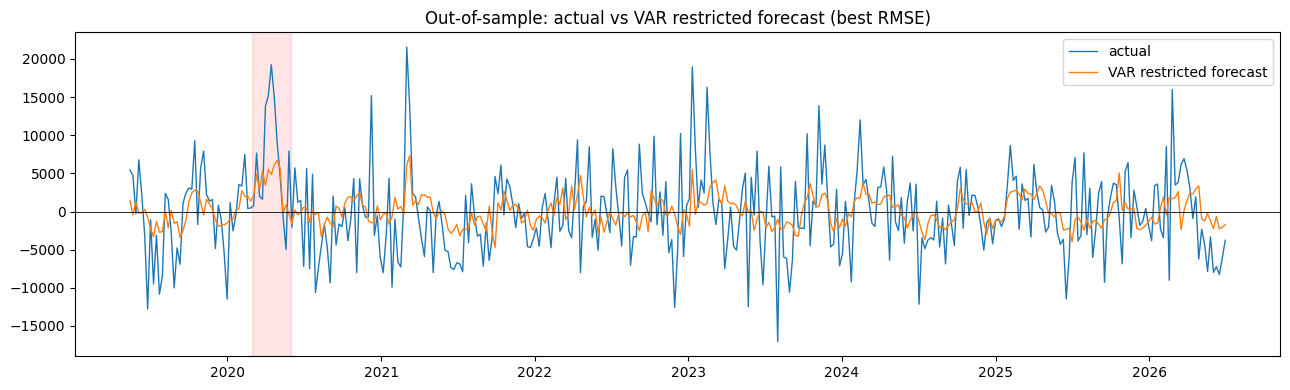

In [39]:
import matplotlib.pyplot as plt

best_predictions = restricted_predictions  # VAR restricted: lowest out-of-sample RMSE

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test.index, test.values, label="actual", linewidth=1)
ax.plot(best_predictions.index, best_predictions.values, label="VAR restricted forecast", linewidth=1)
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-06-01"), color="red", alpha=0.10)
ax.axhline(0, color="black", linewidth=0.6)
ax.legend()
ax.set_title("Out-of-sample: actual vs VAR restricted forecast (best RMSE)")
plt.tight_layout()
plt.show()

#### **COVID robustness — tree models**

The same check as for the linear models: metrics recomputed with the COVID weeks (March–June 2020)
removed, to confirm the tree ranking and the GPR null do not hinge on that episode.


In [40]:
keep = (test.index < pd.Timestamp("2020-03-01")) | (test.index > pd.Timestamp("2020-06-01"))

tree_predictions = {
    "RF restricted": rf_restricted,
    "RF augmented": rf_augmented,
    "XGB restricted": xgb_restricted,
    "XGB augmented": xgb_augmented,
}
tree_results_ex_covid = pd.DataFrame([
    {"model": name, **evaluate(test[keep], prediction[keep])}
    for name, prediction in tree_predictions.items()
])
print("Excluded weeks:", int((~keep).sum()))
print(tree_results_ex_covid.round(3))


Excluded weeks: 13
            model      RMSE       MAE  Directional accuracy
0   RF restricted  5216.097  4027.328                 0.606
1    RF augmented  5197.914  4018.480                 0.619
2  XGB restricted  5124.154  3961.632                 0.647
3   XGB augmented  5117.052  3976.911                 0.644


Dropping the 13 COVID weeks lowers every RMSE and leaves the picture unchanged: the GPR edge stays
tiny and inconsistent (a marginal RF gain, mixed for XGBoost), and no augmented model robustly beats
its restricted counterpart. The H1 null holds without the episode, in the tree models as in the
linear ones.


### **Conclusion**

### Tree-based models — Conclusion

**Non-linearity alone buys nothing.** On the fundamentals only, the tuned trees do
not beat the linear VAR: XGBoost restricted reaches RMSE 5217 against the VAR's
5167, and the random forest is slightly worse. Weekly stock changes do not hide a
strong non-linear structure that the linear system missed, so moving to trees is
not, in itself, an improvement on this target.

**The GPR gain was overfitting.** The untuned trees showed a first small GPR edge,
the only place it had helped anywhere in the study, most clearly in the random
forest (RF augmented RMSE 5183 vs 5221 restricted, direction 65.4% vs 64.3%) and,
larger, in XGBoost. Regularisation removed it. The overfit diagnosis was explicit:
the in-sample-to-out-of-sample RMSE gap fell from about 95% to 46% for XGBoost and
from about 60% to 40% for the forest once the cross-validation pushed both models
to their most regularised settings (shallow trees, large leaves, slow learning
rate). On the honest, regularised models the GPR edge collapses to a marginal +1.3
points of direction in the forest and a marginal loss in XGBoost. Most of the
initial gain was the trees memorising noise, not signal.

**Feature importance confirms the null.** On a single tuned fit, the trees lean on
seasonality (month is the single most important feature), refinery activity and
the target's own lags, exactly the fundamentals and autoregressive structure the
linear models already used. The best GPR feature ranks only 19th of 41, and the
GPR features together carry about a third of the mean importance of the rest. The
regularised trees barely use the GPR, which is a direct, model-internal
confirmation of the vanished forecast gain.

**Robust to COVID.** Removing the 13 COVID weeks (March–June 2020) lowers every
RMSE and leaves the picture unchanged: the GPR edge stays tiny and inconsistent,
and no augmented model robustly beats its restricted counterpart. The tree-based
null does not depend on that episode, just as the linear one did not.

**H1 — overall verdict.** Across the whole study the answer is a clean null. The
GPR added nothing unconditionally (EDA), nothing in the linear conditional setting
(VAR), and nothing robust in the non-linear setting (trees). The two best models
are both restricted and use no GPR at all: the VAR on error (RMSE 5167) and the
tuned XGBoost on direction (65.4%). Geopolitical risk, as measured by the GPR
index of Caldara & Iacoviello (2022)
(https://www.aeaweb.org/articles?id=10.1257/aer.20191823), does not improve the
weekly forecast of US commercial crude stock changes once market fundamentals are
controlled for, in any of the model families tested.

**Reading the result.** This null is informative, not a dead end. Weekly US stock
changes are driven by physical and refining flows (production, refinery runs,
imports) and by a strong seasonal cycle, all of which the fundamentals capture. A
plausible reading is that geopolitical risk operates on the global oil market at a
slower, price and expectations horizon rather than on the high-frequency physical
balance of US inventories, a conjecture that H2 tests directly. The contribution
of the thesis is a rigorous, multi-model incremental test that documents this null
cleanly, which is a defensible finding in itself.

**Implication for the next stage.** H1 is closed. The forecasting evidence says
the GPR does not help predict inventory changes, so the natural question shifts to
H2 and H3, whether the GPR still matters for the price reaction to inventory
surprises and for a trading strategy, even though it does not improve the
inventory forecast itself. The best restricted models identified across the study
(VAR and XGBoost) provide the forecast inputs carried forward to that stage.

## **H2** - WTI price reaction to EIA inventory surprises

H2 tests whether the surprise component of the weekly EIA crude inventory release (actual minus the
analyst consensus) moves the WTI price on the announcement day, with the expected sign: a positive
surprise (more oil than expected) is bearish, a negative surprise bullish, following Bu (2014). The
surprise is also related to the Brent–WTI spread. The consensus is only available from June 2003, so
H2 runs on 2003–2026, shorter than H1's 1990–2026 — a data constraint carried throughout.


#### **1. Loading and preliminary checks**


The Bloomberg exports are European-format: ";" separator, "N/A" for missing values, day-first dates,
and comma decimals in the price file. The inventory file carries the actual change and the survey on
one date axis (the survey blank before 2003); the price file carries daily WTI and Brent (M1, M2) and
OVX. Both are loaded cleanly here and their structure confirmed; the date alignment against H1 — the
Bloomberg dates being the week-ending Friday rather than the publication day — is handled next.

In [44]:
inv_path = "Dataset/Bloomberg/change-crude-oil-inventories-exp-vs-actual.csv"
price_path = "Dataset/Bloomberg/wti-brent-ovx.csv"

# European-locale exports: ";" separator, "N/A" missing, day-first dates; comma decimals in prices.
# utf-8-sig strips the byte-order mark. The inventory date is the week-ending Friday (see next block).
inventory = pd.read_csv(inv_path, sep=";", encoding="utf-8-sig", na_values="N/A")
inventory.columns = ["week_ended", "actual", "survey_median", "survey_average", "survey_count"]
inventory["week_ended"] = pd.to_datetime(inventory["week_ended"], format="%d/%m/%Y")

prices = pd.read_csv(price_path, sep=";", decimal=",", encoding="utf-8-sig", na_values="N/A")
prices.columns = ["date", "wti_m1", "wti_m2", "brent_m1", "brent_m2", "ovx"]
prices["date"] = pd.to_datetime(prices["date"], format="%d/%m/%Y")
prices = prices.set_index("date").sort_index()

print("Inventory:", inventory.shape, "|", inventory["week_ended"].min().date(), "->", inventory["week_ended"].max().date())
print("Survey starts:", inventory.loc[inventory["survey_median"].notna(), "week_ended"].min().date())
print("\nPrices:", prices.shape, "|", prices.index.min().date(), "->", prices.index.max().date())
print("OVX starts:", prices["ovx"].first_valid_index().date())
print("\n", prices.head(3))
print("\n", inventory.tail(3))

Inventory: (1860, 5) | 1990-11-09 -> 2026-06-26
Survey starts: 2003-06-13

Prices: (9529, 5) | 1990-01-01 -> 2026-07-09
OVX starts: 2007-05-10

             wti_m1  wti_m2  brent_m1  brent_m2  ovx
date                                               
1990-01-01   21.82   21.49     20.28     19.69  NaN
1990-01-02   22.89   22.41     20.51     19.90  NaN
1990-01-03   23.68   22.97     21.69     20.95  NaN

      week_ended  actual  survey_median  survey_average  survey_count
1857 2026-06-12   -8263        -3000.0         -3692.0           6.0
1858 2026-06-19   -6088        -3600.0         -3938.0           5.0
1859 2026-06-26   -3775        -2262.0         -2903.0           0.0


**Date alignment against H1 :** Bloomberg could date by the week-ending Friday or by the EIA publication day. Merging on each of H1's
date columns settles it: the convention that matches the values is the right one. The surprise then
uses the Bloomberg actual — the number released on the day — which differs from the revised H1 series
only by headline rounding and later EIA revisions.


In [45]:
h1_weekly = df[["week_ended", "publication_date", "target_stock_change"]]

# Which H1 date convention lines the Bloomberg values up? The one that matches is the right one.
for candidate in ["week_ended", "publication_date"]:
    merged = inventory.rename(columns={"week_ended": candidate}).merge(h1_weekly, on=candidate, how="inner")
    print(f"Read as {candidate:16s}: {len(merged):5d} matched weeks")

# Confirmed as week_ended. Residual value gaps (headline rounding + EIA revisions) are exactly why the
# surprise below uses the Bloomberg actual, not the revised H1 series.
aligned = inventory.merge(h1_weekly, on="week_ended", how="inner")
print("Value gaps:", int((aligned["actual"] != aligned["target_stock_change"]).sum()), "of", len(aligned))


Read as week_ended      :  1860 matched weeks
Read as publication_date:     0 matched weeks
Value gaps: 469 of 1860


*NB pour la these -> Les « 469 value gaps » : parmi les 1860 semaines bien alignées, 469 ont un chiffre légèrement différent entre Bloomberg et H1. C'est normal : le chiffre Bloomberg est celui annoncé le jour même (premier print, parfois arrondi), celui de H1 vient de la série EIA révisée plus tard.*

#### **3. Inventory surprise**


Surprise = announced actual minus the analyst consensus (survey median), from June 2003. A surprise
should be close to unpredictable; strong autocorrelation would signal a biased consensus.

In [46]:
# Surprise = announced actual - consensus (survey median), on the survey period only.
surprise_data = inventory.loc[inventory["survey_median"].notna(),
                              ["week_ended", "actual", "survey_median"]].copy()
surprise_data["surprise"] = surprise_data["actual"] - surprise_data["survey_median"]

print("Obs:", len(surprise_data), "|",
      surprise_data["week_ended"].min().date(), "->", surprise_data["week_ended"].max().date())
print(surprise_data["surprise"].describe().round(1))
print("Share positive:", round((surprise_data["surprise"] > 0).mean(), 3))
print("Autocorrelation (lag 1):", round(surprise_data["surprise"].autocorr(1), 3))


Obs: 1200 | 2003-06-13 -> 2026-06-26
count     1200.0
mean       133.1
std       4103.0
min     -15999.0
25%      -2330.0
50%         84.5
75%       2498.8
max      22863.0
Name: surprise, dtype: float64
Share positive: 0.507
Autocorrelation (lag 1): -0.05


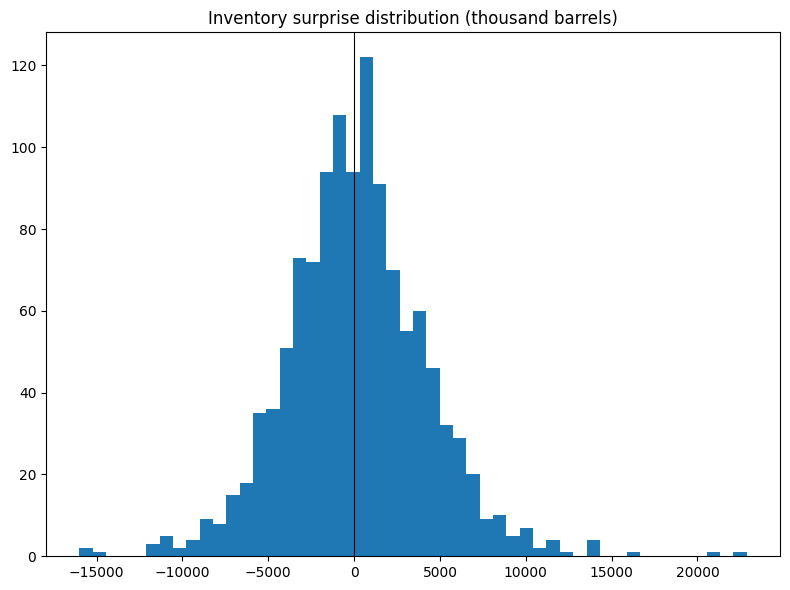

In [48]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(surprise_data["surprise"], bins=50)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Inventory surprise distribution (thousand barrels)")
plt.tight_layout()
plt.show()

The surprise is well-behaved: mean 133 and median 85 (near zero against a std of ~4100), about half
positive (0.507), and negligible lag-1 autocorrelation (−0.05). The consensus is unbiased and the
surprise unpredictable, as an efficient consensus should be — a clean shock for the event study.

#### **4. Announcement-day returns**




The reaction is measured on the release day — the Wednesday after the week ends, shifted to Thursday
on federal-holiday weeks — as the close-to-close log return of WTI M1 (and Brent M1). The Brent–WTI
spread change keeps only days where both prices exist, since NYMEX and ICE holidays differ.

In [49]:
from pandas.tseries.holiday import USFederalHolidayCalendar

us_holidays = set(USFederalHolidayCalendar().holidays(start="2000-01-01", end="2030-12-31"))

def eia_release_date(week_ended_friday):
    # Release = following Wednesday (Friday + 5), shifted to Thursday if a federal holiday falls
    # Mon-Wed of that week. The exact day matters for the announcement-day return.
    wednesday = week_ended_friday + pd.Timedelta(days=5)
    if any((wednesday - pd.Timedelta(days=offset)) in us_holidays for offset in (0, 1, 2)):
        return wednesday + pd.Timedelta(days=1)
    return wednesday

# Daily close-to-close log returns; spread = Brent M1 - WTI M1 (dollars). NaN where a price is missing.
daily = prices[["wti_m1", "brent_m1"]].copy()
daily["wti_return"] = np.log(daily["wti_m1"] / daily["wti_m1"].shift(1))
daily["brent_return"] = np.log(daily["brent_m1"] / daily["brent_m1"].shift(1))
daily["spread_change"] = (daily["brent_m1"] - daily["wti_m1"]).diff()

# Announcement day for each surprise, then attach that day's returns.
surprise_data["release_date"] = surprise_data["week_ended"].apply(eia_release_date)
event = surprise_data.merge(daily[["wti_return", "brent_return", "spread_change"]],
                            left_on="release_date", right_index=True, how="left")

print("Events:", len(event), "| with WTI return:", int(event["wti_return"].notna().sum()))
print("Release weekday:", event["release_date"].dt.day_name().value_counts().to_dict())
print(event[["week_ended", "release_date", "surprise", "wti_return", "spread_change"]].tail())


Events: 1200 | with WTI return: 1200
Release weekday: {'Wednesday': 1030, 'Thursday': 170}
     week_ended release_date  surprise  wti_return  spread_change
1855 2026-05-29   2026-06-03   -4924.0    0.023818          -0.45
1856 2026-06-05   2026-06-10   -5027.0    0.020536          -0.18
1857 2026-06-12   2026-06-17   -5263.0    0.009683          -0.15
1858 2026-06-19   2026-06-24   -2488.0   -0.039991          -0.47
1859 2026-06-26   2026-07-01   -1513.0   -0.013326          -0.43


All 1200 events have a matching announcement-day return. 170 of them (14%) fall on a Thursday from the
holiday shift, so dating them on the nominal Wednesday would have mis-measured one event in seven. The
surprise, returns and spread change are now aligned on the right day.

#### **5. Main test — price reaction to the surprise (Bu, 2014)**




The announcement-day WTI return is regressed on the surprise, with heteroskedasticity-robust (HC1)
standard errors. The expected coefficient is negative: a positive surprise (more oil than expected) is
bearish. The surprise is scaled to million barrels so the coefficient reads as the return per
one-million-barrel surprise.

In [51]:
import statsmodels.api as sm

event_clean = event.dropna(subset=["wti_return", "surprise"]).copy()
event_clean["surprise_mb"] = event_clean["surprise"] / 1000  # million barrels, readable coefficient

model = sm.OLS(event_clean["wti_return"], sm.add_constant(event_clean["surprise_mb"])).fit(cov_type="HC1")
print(model.summary().tables[1])
print("R-squared:", round(model.rsquared, 4), "| n =", int(model.nobs))


                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0009      0.001      1.058      0.290      -0.001       0.002
surprise_mb    -0.0009      0.000     -4.984      0.000      -0.001      -0.001
R-squared: 0.018 | n = 1200


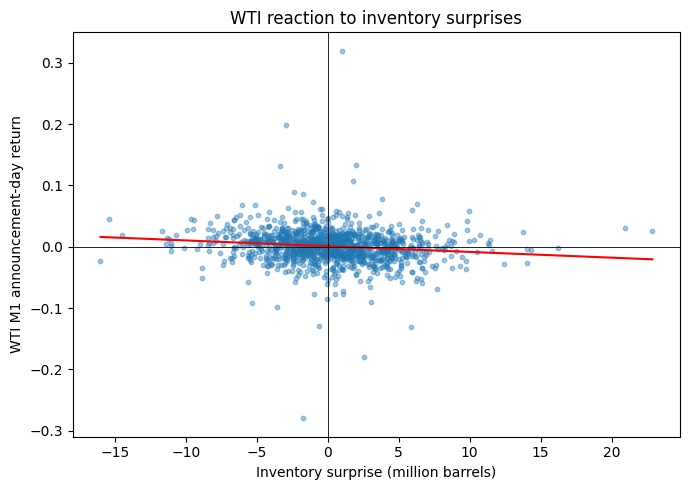

In [52]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(event_clean["surprise_mb"], event_clean["wti_return"], s=10, alpha=0.4)
line_x = np.array([event_clean["surprise_mb"].min(), event_clean["surprise_mb"].max()])
ax.plot(line_x, model.params["const"] + model.params["surprise_mb"] * line_x, color="red")
ax.axhline(0, color="black", linewidth=0.6)
ax.axvline(0, color="black", linewidth=0.6)
ax.set_xlabel("Inventory surprise (million barrels)")
ax.set_ylabel("WTI M1 announcement-day return")
ax.set_title("WTI reaction to inventory surprises")
plt.tight_layout()
plt.show()

H2 holds: the surprise coefficient is −0.0009 per million barrels and highly significant (robust z =
−5.0, p < 0.001), with the expected negative sign — a positive surprise is bearish, as in Bu (2014). A
one-standard-deviation surprise (~4 Mb) moves WTI by about −0.4% on the day. The R² is only 1.8%, so
the surprise is a real but small driver of the announcement-day return.

#### **5b. Surprise and the Brent–WTI spread**


The surprise is a US-specific shock, so it should move WTI more than Brent: a positive surprise (a US
build) is expected to widen the Brent–WTI spread. The spread change is regressed on the surprise with
robust standard errors — a positive, significant coefficient means the surprise is WTI-specific rather
than a global oil shock.

In [58]:
spread_event = event_clean.dropna(subset=["spread_change", "surprise_mb"])
spread_model = sm.OLS(spread_event["spread_change"],
                      sm.add_constant(spread_event["surprise_mb"])).fit(cov_type="HC1")
print(spread_model.summary().tables[1])
print("R-squared:", round(spread_model.rsquared, 4), "| n =", int(spread_model.nobs))


                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0183      0.023      0.788      0.431      -0.027       0.064
surprise_mb     0.0138      0.005      2.808      0.005       0.004       0.023
R-squared: 0.0049 | n = 1200


The surprise widens the Brent–WTI spread: coefficient +0.014 $/bbl per million barrels, significant
(z = 2.8, p = 0.005). A US inventory surprise is therefore a WTI-specific shock — it moves WTI relative
to Brent in the expected direction — not a global oil shock. The effect is small (R² 0.5%) but robust.

#### **6. Asymmetry**




Bu (2014) finds the reaction differs across regimes. The simplest version is tested here: the slope
is allowed to differ for positive and negative surprises through an interaction term. A significant
interaction coefficient means the price reacts more strongly to one sign than the other.

In [53]:
event_clean["positive"] = (event_clean["surprise_mb"] > 0).astype(int)
event_clean["surprise_x_positive"] = event_clean["surprise_mb"] * event_clean["positive"]

asym = sm.OLS(event_clean["wti_return"],
              sm.add_constant(event_clean[["surprise_mb", "surprise_x_positive"]])).fit(cov_type="HC1")
print(asym.summary().tables[1])

slope_negative = asym.params["surprise_mb"]
slope_positive = asym.params["surprise_mb"] + asym.params["surprise_x_positive"]
print(f"\nSlope, negative surprises: {slope_negative:.5f}")
print(f"Slope, positive surprises: {slope_positive:.5f}")


                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.0004      0.001     -0.304      0.761      -0.003       0.002
surprise_mb            -0.0014      0.000     -3.972      0.000      -0.002      -0.001
surprise_x_positive     0.0008      0.001      1.415      0.157      -0.000       0.002

Slope, negative surprises: -0.00138
Slope, positive surprises: -0.00056


The interaction is not significant (z = 1.4, p = 0.16), so the reaction is statistically symmetric. The
point estimates do hint at a stronger response to negative surprises (draws, slope −0.0014) than to
positive ones (builds, −0.0006), but the difference cannot be established at conventional levels. The
effect stays firmly negative on both sides.

#### **7. GPR interaction — does risk amplify the reaction?**


This is the link back to H1. If geopolitical risk operates through prices and expectations rather than
the physical balance — the conjecture from H1's conclusion — the price should react more strongly to
inventory surprises when GPR is high. The surprise slope is allowed to differ between high-GPR weeks
(top quartile) and the rest.

In [54]:
# Attach the weekly GPR (from H1) to each event, then let the surprise slope differ in high-GPR weeks.
event_clean["gprd"] = event_clean["week_ended"].map(df.set_index("week_ended")["gprd"])
event_gpr = event_clean.dropna(subset=["gprd"]).copy()

event_gpr["high_gpr"] = (event_gpr["gprd"] > event_gpr["gprd"].quantile(0.75)).astype(int)
event_gpr["surprise_x_highgpr"] = event_gpr["surprise_mb"] * event_gpr["high_gpr"]

gpr_model = sm.OLS(event_gpr["wti_return"],
                   sm.add_constant(event_gpr[["surprise_mb", "high_gpr", "surprise_x_highgpr"]])).fit(cov_type="HC1")
print(gpr_model.summary().tables[1])

slope_low = gpr_model.params["surprise_mb"]
slope_high = gpr_model.params["surprise_mb"] + gpr_model.params["surprise_x_highgpr"]
print(f"\nSlope, normal weeks : {slope_low:.5f}")
print(f"Slope, high-GPR weeks: {slope_high:.5f}")


                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0011      0.001      1.115      0.265      -0.001       0.003
surprise_mb           -0.0009      0.000     -3.830      0.000      -0.001      -0.000
high_gpr              -0.0008      0.002     -0.410      0.682      -0.004       0.003
surprise_x_highgpr    -0.0003      0.000     -0.677      0.498      -0.001       0.001

Slope, normal weeks : -0.00086
Slope, high-GPR weeks: -0.00113


The interaction is not significant (z = −0.7, p = 0.50): the reaction to surprises is statistically the
same in high-GPR weeks (slope −0.0011) and normal weeks (−0.0009). The conjecture from H1 — that GPR
works through the price reaction rather than the physical balance — is not supported. The surprise
itself stays significant; geopolitical risk simply does not amplify it.

#### **8. Do the H1 forecasts beat the consensus?**

If the H1 models carry information beyond the analyst consensus, their deviation from it should predict
the surprise. The surprise is regressed on (model forecast − survey median) for the best restricted
models, over the H1 test period. A positive, significant slope means an exploitable edge for H3;
otherwise the consensus is efficient. (These forecasts use revised features — a first look, to be
confirmed on first-print inputs.)

In [55]:
# Map the H1 forecasts (indexed by publication_date) to week_ended, then join to the events.
pub_to_week = df.set_index("publication_date")["week_ended"]
h1_forecasts = pd.DataFrame({
    "week_ended": pub_to_week.reindex(restricted_predictions.index).values,
    "var_forecast": restricted_predictions.values,
    "xgb_forecast": xgb_restricted.values,
})
consensus_test = event_clean.merge(h1_forecasts, on="week_ended", how="inner")

# Does (model forecast - survey) predict the surprise (actual - survey)?
for model_name in ["var_forecast", "xgb_forecast"]:
    deviation = consensus_test[model_name] - consensus_test["survey_median"]
    fit = sm.OLS(consensus_test["surprise"], sm.add_constant(deviation)).fit(cov_type="HC1")
    print(f"{model_name}: coef={fit.params.iloc[1]:.3f}, t={fit.tvalues.iloc[1]:.2f}, "
          f"R2={fit.rsquared:.3f}, n={int(fit.nobs)}")


var_forecast: coef=0.573, t=3.11, R2=0.045, n=373
xgb_forecast: coef=0.505, t=3.73, R2=0.043, n=373


Both models carry information beyond the consensus: their deviation from the survey predicts the
surprise with a positive, significant slope (VAR coef 0.57, t = 3.1; XGBoost 0.51, t = 3.7; R² ~4.5%).
This is a promising, exploitable edge for H3 — the models are not redundant with the analysts. It rests
on revised features, so it must be re-run on first-print inputs before H3 builds on it.

#### **9. COVID robustness**


The main test is re-run with the COVID weeks (March–June 2020) removed, as in H1, to confirm the price
reaction to surprises is not driven by that extreme period.

In [56]:
covid_start, covid_end = pd.Timestamp("2020-03-01"), pd.Timestamp("2020-06-01")
ex_covid = event_clean[(event_clean["release_date"] < covid_start) | (event_clean["release_date"] > covid_end)]

model_ex_covid = sm.OLS(ex_covid["wti_return"], sm.add_constant(ex_covid["surprise_mb"])).fit(cov_type="HC1")

comparison = pd.DataFrame({
    "coef": [model.params["surprise_mb"], model_ex_covid.params["surprise_mb"]],
    "t_stat": [model.tvalues["surprise_mb"], model_ex_covid.tvalues["surprise_mb"]],
    "R2": [model.rsquared, model_ex_covid.rsquared],
    "n": [int(model.nobs), int(model_ex_covid.nobs)],
}, index=["full", "ex-COVID"])
print(comparison.round(4))


            coef  t_stat      R2     n
full     -0.0009 -4.9835  0.0180  1200
ex-COVID -0.0010 -5.2568  0.0249  1187


Removing the 13 COVID weeks leaves the result intact, in fact slightly stronger: the coefficient holds
at −0.0010 (t = −5.3) and the R² rises to 2.5%. The COVID period added noise rather than driving the
effect, so H2's main finding does not depend on it.

In [57]:
# Attach OVX on the announcement day, then save the event-level dataset for H3.
event_clean["ovx"] = event_clean["release_date"].map(prices["ovx"])

h2_dataset = event_clean[["release_date", "week_ended", "actual", "survey_median", "surprise",
                          "wti_return", "brent_return", "spread_change", "gprd"]].copy()
h2_dataset = h2_dataset.rename(columns={"release_date": "announcement_date"})
h2_dataset.to_csv("Dataset/H2_dataset.csv", index=False)

print(h2_dataset.shape)
h2_dataset.tail()

(1200, 9)


,announcement_date,week_ended,actual,survey_median,surprise,wti_return,brent_return,spread_change,gprd
1855,2026-06-03,2026-05-29,-7974,-3050.0,-4924.0,0.023818,0.018679,-0.45,179.123333
1856,2026-06-10,2026-06-05,-7227,-2200.0,-5027.0,0.020536,0.017882,-0.18,189.318333
1857,2026-06-17,2026-06-12,-8263,-3000.0,-5263.0,0.009683,0.007444,-0.15,222.936667
1858,2026-06-24,2026-06-19,-6088,-3600.0,-2488.0,-0.039991,-0.044298,-0.47,204.183333
1859,2026-07-01,2026-06-26,-3775,-2262.0,-1513.0,-0.013326,-0.018687,-0.43,169.961667


#### **Conclusion**

**The surprise moves the price, with the expected sign.** On 1200 announcement
days from June 2003 to July 2026, the WTI return reacts negatively and highly
significantly to the inventory surprise: a coefficient of −0.0009 per million
barrels (robust z = −5.0, p < 0.001), meaning a one-standard-deviation surprise
(about 4 Mb) moves WTI by roughly −0.4% on the day. The sign and the mechanism
are exactly those documented by Bu (2014)
(https://www.sciencedirect.com/science/article/abs/pii/S0140988314001236): more
oil than expected is bearish, less is bullish. H2 is validated.

**A real but small driver.** The R² of the event regression is 1.8%: the
surprise is one identifiable driver of the announcement-day return among many,
not its main determinant. This is the expected order of magnitude for a single
scheduled release in a market also moving on global news, and it frames what a
surprise-based strategy can hope to extract in H3.

**The surprise is a clean shock.** The consensus is unbiased (mean surprise 133
thousand barrels against a standard deviation of ~4100, half the surprises
positive) and the surprise is serially uncorrelated (lag-1 autocorrelation
−0.05). The analyst survey behaves as an efficient forecast should, which makes
the event study well-identified and makes beating that consensus a meaningful
bar.

**The surprise is a WTI-specific shock, confirmed on the Brent–WTI spread.** A
positive surprise widens the spread by +0.014 $/bbl per million barrels
(z = 2.8, p = 0.005, R² 0.5%): a US build weakens WTI relative to Brent, in the
expected direction. The announcement therefore moves the US benchmark relative
to the global one rather than shifting the whole oil complex, which is exactly
what a US-specific physical shock should do, and it validates the role assigned
to the spread in the research design as a transmission test.

**The reaction is statistically symmetric.** Allowing the slope to differ for
builds and draws, the interaction is not significant (p = 0.16). The point
estimates hint at a stronger reaction to draws (−0.0014) than to builds
(−0.0006), directionally consistent with the regime-dependence in Bu (2014), but
the difference cannot be established at conventional levels on this sample.

**Geopolitical risk does not amplify the reaction.** This was the conjecture
carried over from H1: if the GPR operates through prices and expectations rather
than the physical balance, high-GPR weeks should react more strongly to a given
surprise. They do not (interaction p = 0.50; slope −0.0011 in top-quartile GPR
weeks vs −0.0009 elsewhere). Combined with the H1 null, the picture is now
consistent across both hypotheses: geopolitical risk, as measured by the index of
Caldara & Iacoviello (2022)
(https://www.aeaweb.org/articles?id=10.1257/aer.20191823), neither predicts the
weekly physical balance nor conditions the market's reaction to it. The surprise
effect itself is robust to excluding the COVID weeks (coefficient −0.0010,
z = −5.3 ex-COVID).

**The H1 models carry information the consensus does not.** Potentially the most
consequential result of this chapter: over the H1 test period, the deviation of
the restricted VAR and XGBoost forecasts from the survey median predicts the
realised surprise with positive, significant slopes (VAR 0.57, t = 3.1; XGBoost
0.51, t = 3.7; R² ≈ 4.5%). The models built in H1 are not redundant with the
analysts, even though they use no geopolitical information. One caveat is
attached and must be resolved before H3: these forecasts were produced on
revised EIA features, not the first-print data available in real time, so the
edge must be re-confirmed on first-print inputs before any trading conclusion is
drawn.

**Opening toward H3**

H2 establishes the two ingredients a strategy needs: a price that reliably reacts
to the surprise, and a forecast that anticipates part of that surprise. It also
identifies where to trade it: the reaction lives in WTI (and in WTI relative to
Brent), so the natural instruments are the WTI outright and the Brent–WTI
spread, consistent with the instrument hierarchy set in the research design. H3
tests whether these ingredients combine into tradable value: a systematic
position taken on the predicted surprise (model forecast minus survey median),
evaluated on announcement-day returns, net of realistic transaction costs, and
measured against the risk premia documented in crude oil futures by Hamilton & Wu
(2014)
(https://www.sciencedirect.com/science/article/abs/pii/S0261560613001058), so
that any remaining performance is alpha rather than compensation for known risk.

Three open points from H2 carry into H3. First, the revised-vs-first-print caveat
above: the exploitable edge must survive real-time inputs. Second, the small R²
of every link in the chain (1.8% on the WTI reaction, 0.5% on the spread, 4.5%
on the forecast edge) sets realistic expectations: the strategy monetises a
thin, noisy signal, and transaction costs will matter. Third, the GPR question
is settled for the physical channel, and since the H1 models use no geopolitical
information, the H3 strategy, if profitable, would be an inventory-fundamentals
strategy, not a geopolitical one; that finding would itself close the thesis
narrative consistently.

# H3 — A surprise-based trading strategy

H3 tests whether the predicted surprise (model forecast minus the analyst consensus) can be traded on
the announcement day for a significant alpha, net of realistic costs and after controlling for known
oil-futures risk premia. Following the H1 null, the strategy uses the restricted models (no GPR): if it
is profitable, it is an inventory-fundamentals strategy, not a geopolitical one.
